# Exploratory Data Analysis: Multivariate Analysis

The objective of this section is to examine and interpret the relationships among multiple variables simultaneously within the student performance dataset. Multivariate analysis is conducted to understand how combinations of academic, behavioral, and demographic factors interact and collectively influence student outcomes, going beyond pairwise relationships.

The analysis focuses on key groups of variables—such as student grades, motivation levels, study habits, attendance, and demographic characteristics—to identify complex patterns, interactions, and underlying structures in performance and behavior. Visualization and analytical techniques including heatmaps, multivariate scatterplots, correlation matrices, and dimensionality reduction methods (e.g., PCA) are used to capture these relationships and highlight interactions across multiple features.

The datasets used in this analysis are:

- `ensia_cleaned_1Y_grouped_imputed.csv`
- `ensia_cleaned_2Y_grouped_imputed.csv`
- `ensia_cleaned_3Y_grouped_imputed.csv`

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [2]:
# Reading data from csv files 
data_1y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_1Y_grouped_imputed.csv')
data_2y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_2Y_grouped_imputed.csv')
data_3y = pd.read_csv('../data/outputs/grouped_imputed/ensia_cleaned_3Y_grouped_imputed.csv')

print("Data Loaded Successfully")
print(f"\nData 1Y shape: {data_1y.shape}")
print(f"Data 2Y shape: {data_2y.shape}")
print(f"Data 3Y shape: {data_3y.shape}")

# Display numeric columns for reference
print("\n Numeric columns in 1Y data -for reference- :")
numeric_cols_1y = data_1y.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols_1y)

Data Loaded Successfully

Data 1Y shape: (210, 45)
Data 2Y shape: (101, 45)
Data 3Y shape: (12, 45)

 Numeric columns in 1Y data -for reference- :
['record_id', 'rate your satisfaction with the school s program', 'your level of motivation for joining ensia', 'how much do you like the field of artificial intelligence', 'how well do you handle stress and pressure', 'in a scale of 1 to 10 how do you rate your level in the following fields 1 english', '2 programming', '3 computer science', '4 mathematics', 'year_ordinal', 'inferred_year_from_grades', '1y average s1', '1y average s2', '1y average', '1Y_math_avg', '1Y_math_n', '1Y_programming_avg', '1Y_programming_n', '1Y_other_avg', '1Y_other_n', '1Y_all_modules_avg', '1Y_all_modules_n']


---
# 1. Correlation Analysis

Correlation measures the strength and direction of linear relationships between pairs of variables.
- **Pearson correlation**: Measures linear relationships (assumes normality)
- **Spearman correlation**: Measures monotonic relationships (rank-based, robust to outliers)

In [3]:
# Select numeric columns for each dataset (excluding record_id)
def get_numeric_columns(df):
    """Select numeric columns excluding record_id"""
    numeric_df = df.select_dtypes(include=[np.number])
    # Drop record_id if present
    cols_to_drop = [col for col in numeric_df.columns if 'record_id' in col.lower()]
    return numeric_df.drop(columns=cols_to_drop, errors='ignore')

# Hardcoded column name mappings for visualization
COLUMN_SHORT_NAMES = {
    # Survey questions
    'rate your satisfaction with the school s program': 'satisfaction',
    'your level of motivation for joining ensia': 'motivation',
    'how much do you like the field of artificial intelligence': 'AI interest',
    'how well do you handle stress and pressure': 'stress handling',
    'how do other s feedback influence you': 'feedback influence',
    'how do others feedbacks influence you': 'feedback influence 2',
    'how many hours do you sleep': 'sleep hrs',
    
    # Self-rated skills (scale 1-10)
    'in a scale of 1 to 10 how do you rate your level in the following fields 1 english': 'english level',
    '2 programming': 'prog level',
    '3 computer science': 'CS level',
    '4 mathematics': 'math level',
    '4 forth': 'forth level',
    
    # Problem ranking (1-8)
    'for the next 8 questions you will have a list of problems obstacles classify them according to how much they influence your studies 1 first': 'problem 1',
    '2 second': 'problem 2',
    '3 third': 'problem 3',
    '4 fourth': 'problem 4',
    '5 fifth': 'problem 5',
    '6 sixth': 'problem 6',
    '7 seventh': 'problem 7',
    '8 eighth': 'problem 8',
    
    # Year indicators
    'year_ordinal': 'year',
    'inferred_year_from_grades': 'inferred year',
    
    # 1Y grades
    '1y average s1': '1Y avg S1',
    '1y average s2': '1Y avg S2',
    '1y average': '1Y avg',
    '1Y_math_avg': '1Y math',
    '1Y_math_n': '1Y math n',
    '1Y_programming_avg': '1Y prog',
    '1Y_programming_n': '1Y prog n',
    '1Y_other_avg': '1Y other',
    '1Y_other_n': '1Y other n',
    '1Y_all_modules_avg': '1Y all',
    '1Y_all_modules_n': '1Y all n',
    
    # 2Y grades
    '2y average s1': '2Y avg S1',
    '2y average s2': '2Y avg S2',
    '2y average': '2Y avg',
    '2Y_math_avg': '2Y math',
    '2Y_math_n': '2Y math n',
    '2Y_programming_avg': '2Y prog',
    '2Y_programming_n': '2Y prog n',
    '2Y_other_avg': '2Y other',
    '2Y_other_n': '2Y other n',
    '2Y_all_modules_avg': '2Y all',
    '2Y_all_modules_n': '2Y all n',
    
    # 3Y grades
    '3y average s1': '3Y avg S1',
    '3y average s2': '3Y avg S2',
    '3y average': '3Y avg',
    '3Y_math_avg': '3Y math',
    '3Y_math_n': '3Y math n',
    '3Y_programming_avg': '3Y prog',
    '3Y_programming_n': '3Y prog n',
    '3Y_other_avg': '3Y other',
    '3Y_other_n': '3Y other n',
    '3Y_all_modules_avg': '3Y all',
    '3Y_all_modules_n': '3Y all n',
}

def get_short_name(col):
    """Get short name for a column, return original if not mapped"""
    return COLUMN_SHORT_NAMES.get(col, col)

def get_short_names(columns):
    """Get mapping of original to shortened names for given columns"""
    return {col: get_short_name(col) for col in columns}

numeric_1y = get_numeric_columns(data_1y)
numeric_2y = get_numeric_columns(data_2y)
numeric_3y = get_numeric_columns(data_3y)

# Create short name mappings
short_names_1y = get_short_names(numeric_1y.columns)
short_names_2y = get_short_names(numeric_2y.columns)
short_names_3y = get_short_names(numeric_3y.columns)

print(f"Numeric features in 1Y: {numeric_1y.shape[1]}")
print(f"Numeric features in 2Y: {numeric_2y.shape[1]}")
print(f"Numeric features in 3Y: {numeric_3y.shape[1]}")
print(f"\nColumn name mapping:")
for orig, short in short_names_1y.items():
    print(f"  '{orig}' -> '{short}'")

Numeric features in 1Y: 21
Numeric features in 2Y: 20
Numeric features in 3Y: 21

Column name mapping:
  'rate your satisfaction with the school s program' -> 'satisfaction'
  'your level of motivation for joining ensia' -> 'motivation'
  'how much do you like the field of artificial intelligence' -> 'AI interest'
  'how well do you handle stress and pressure' -> 'stress handling'
  'in a scale of 1 to 10 how do you rate your level in the following fields 1 english' -> 'english level'
  '2 programming' -> 'prog level'
  '3 computer science' -> 'CS level'
  '4 mathematics' -> 'math level'
  'year_ordinal' -> 'year'
  'inferred_year_from_grades' -> 'inferred year'
  '1y average s1' -> '1Y avg S1'
  '1y average s2' -> '1Y avg S2'
  '1y average' -> '1Y avg'
  '1Y_math_avg' -> '1Y math'
  '1Y_math_n' -> '1Y math n'
  '1Y_programming_avg' -> '1Y prog'
  '1Y_programming_n' -> '1Y prog n'
  '1Y_other_avg' -> '1Y other'
  '1Y_other_n' -> '1Y other n'
  '1Y_all_modules_avg' -> '1Y all'
  '1Y_all

### 1.1 Pearson Correlation Matrix
Pearson correlation coefficient ranges from -1 to +1, where:
- +1 indicates perfect positive linear relationship
- -1 indicates perfect negative linear relationship
- 0 indicates no linear relationship

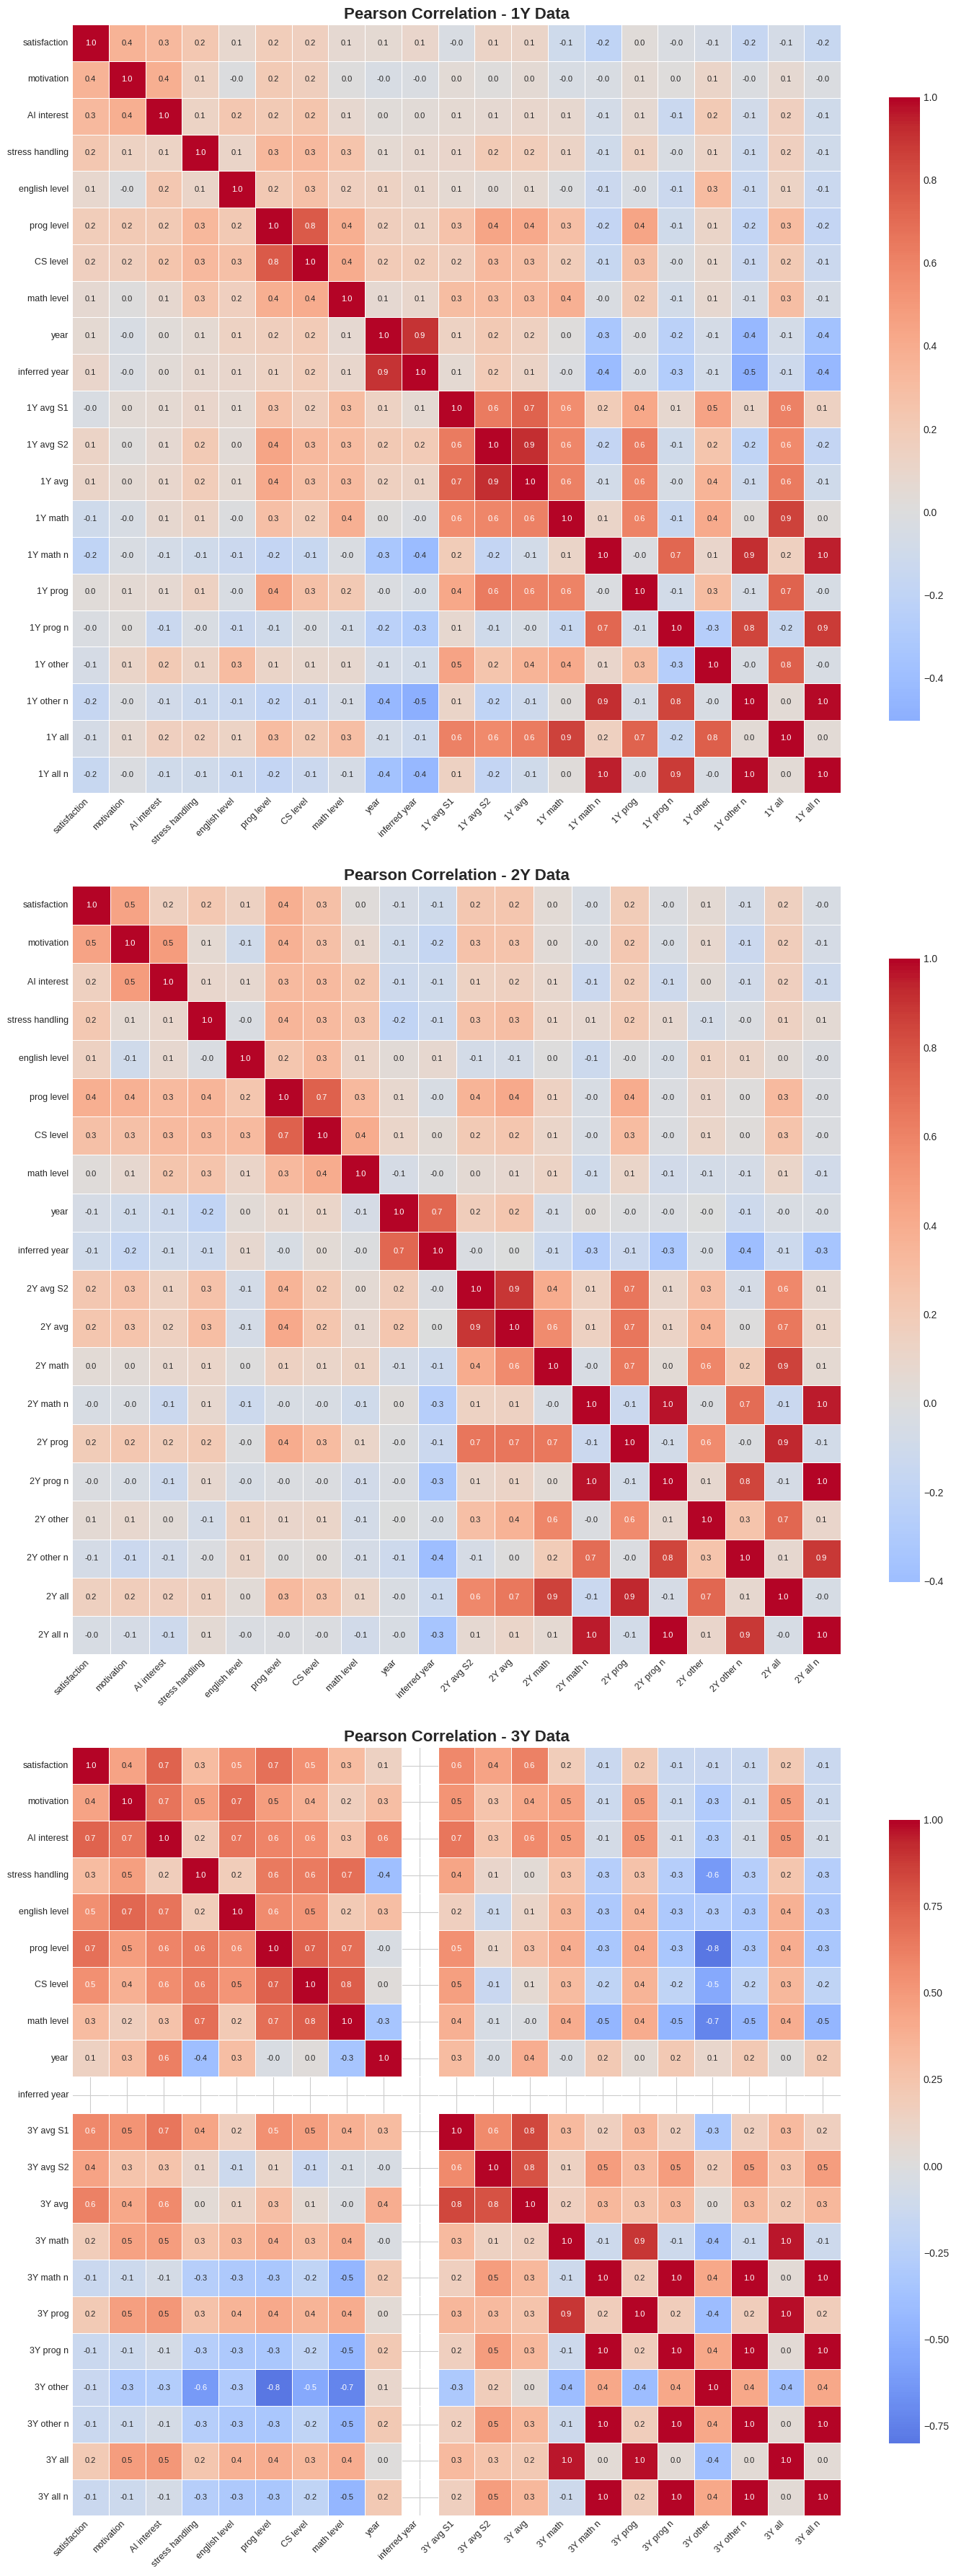

In [4]:
# Pearson Correlation Matrices for all three years
fig, axes = plt.subplots(3, 1, figsize=(14, 36))

# 1Y Pearson Correlation
pearson_1y = numeric_1y.corr(method='pearson')
pearson_1y_display = pearson_1y.copy()
pearson_1y_display.index = [short_names_1y[c] for c in pearson_1y_display.index]
pearson_1y_display.columns = [short_names_1y[c] for c in pearson_1y_display.columns]
sns.heatmap(pearson_1y_display, annot=True, cmap='coolwarm', center=0, fmt='.1f', 
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('Pearson Correlation - 1Y Data', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# 2Y Pearson Correlation
pearson_2y = numeric_2y.corr(method='pearson')
pearson_2y_display = pearson_2y.copy()
pearson_2y_display.index = [short_names_2y[c] for c in pearson_2y_display.index]
pearson_2y_display.columns = [short_names_2y[c] for c in pearson_2y_display.columns]
sns.heatmap(pearson_2y_display, annot=True, cmap='coolwarm', center=0, fmt='.1f', 
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('Pearson Correlation - 2Y Data', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

# 3Y Pearson Correlation
pearson_3y = numeric_3y.corr(method='pearson')
pearson_3y_display = pearson_3y.copy()
pearson_3y_display.index = [short_names_3y[c] for c in pearson_3y_display.index]
pearson_3y_display.columns = [short_names_3y[c] for c in pearson_3y_display.columns]
sns.heatmap(pearson_3y_display, annot=True, cmap='coolwarm', center=0, fmt='.1f', 
            ax=axes[2], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[2].set_title('Pearson Correlation - 3Y Data', fontsize=16, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', rotation=0, labelsize=9)
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

### 1.2 Spearman Correlation Matrix
Spearman correlation is based on ranked values, making it more robust to outliers and suitable for non-linear monotonic relationships.

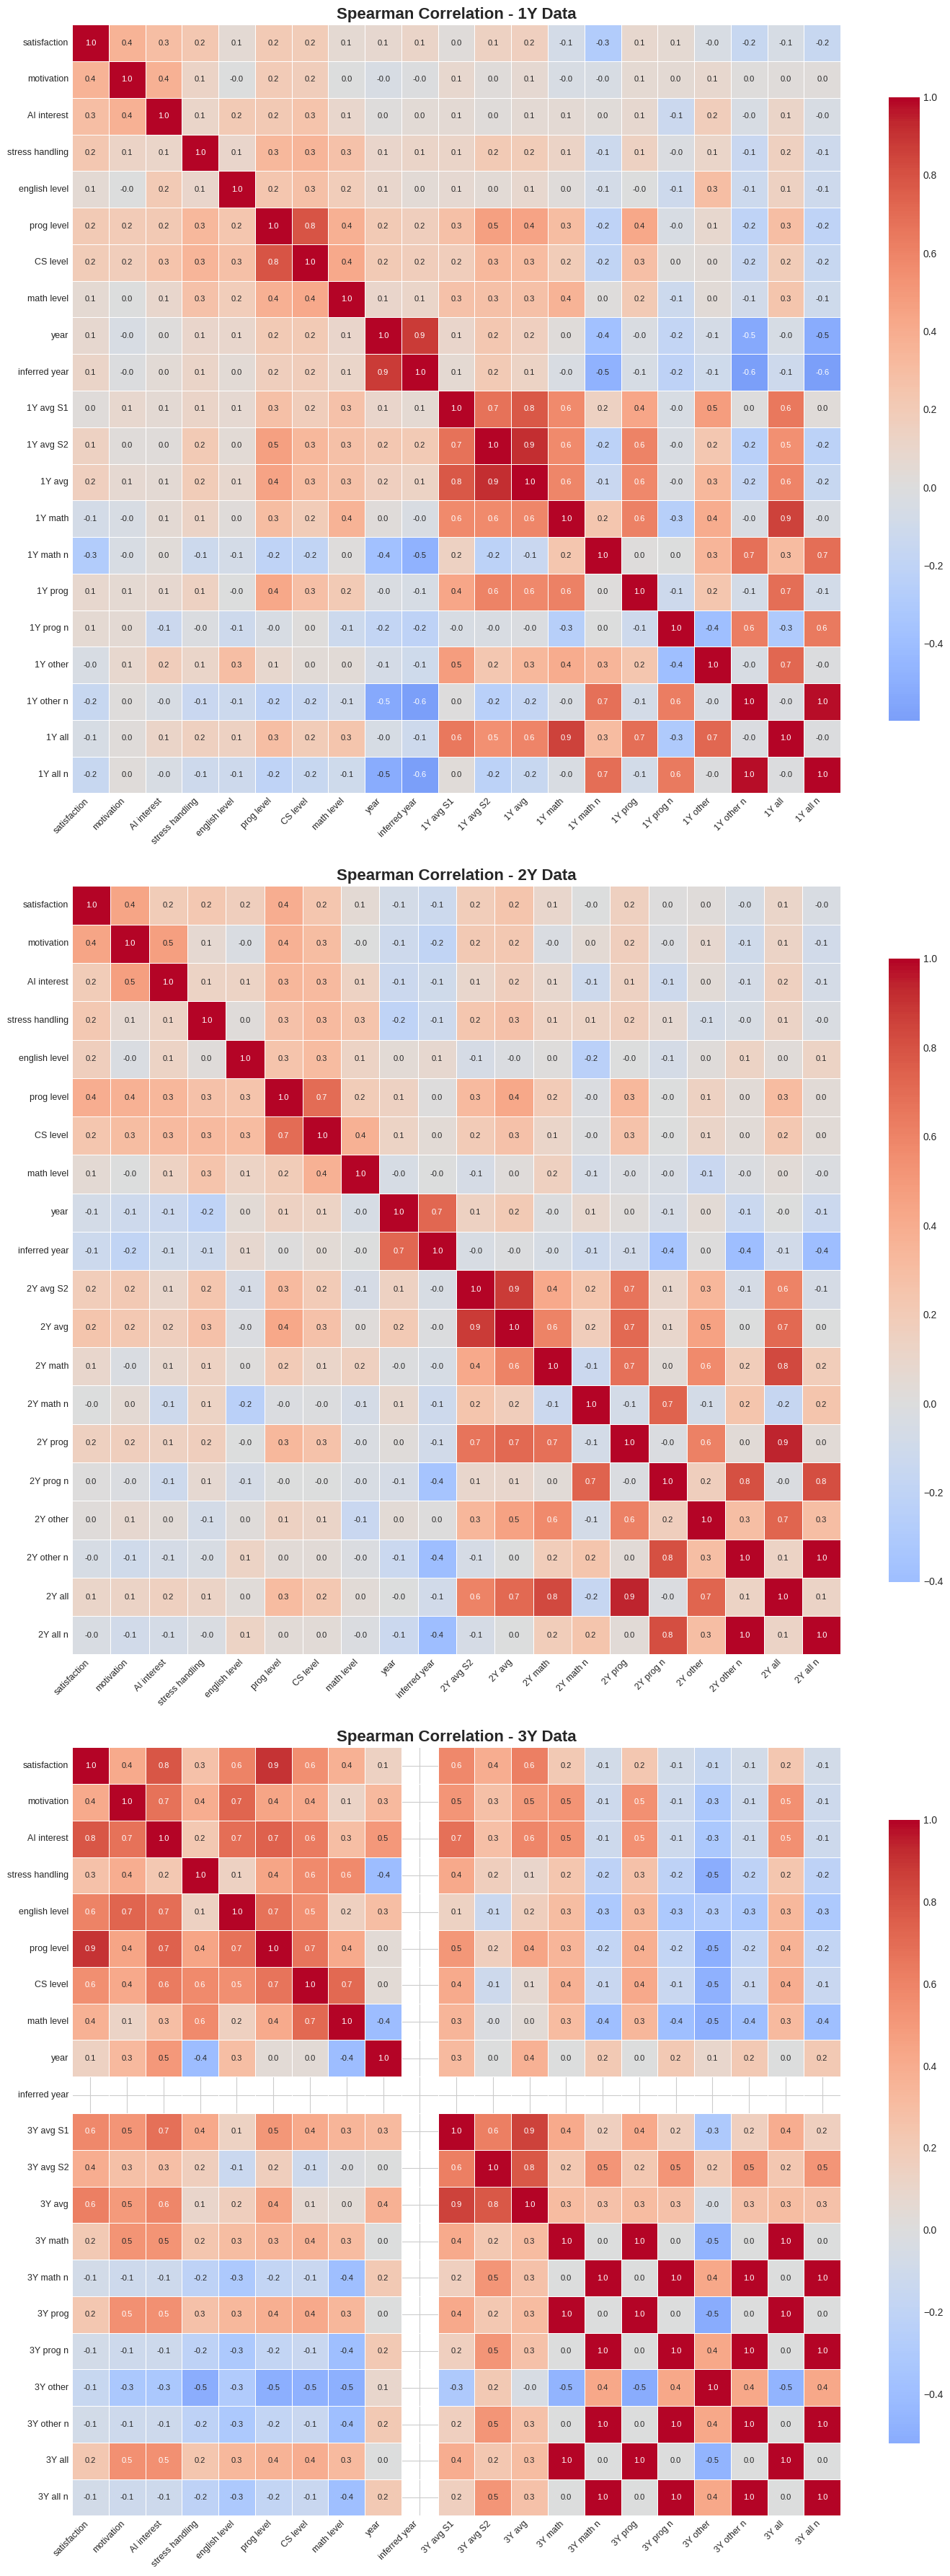

In [5]:
# Spearman Correlation Matrices for all three years
fig, axes = plt.subplots(3, 1, figsize=(14, 36))

# 1Y Spearman Correlation
spearman_1y = numeric_1y.corr(method='spearman')
spearman_1y_display = spearman_1y.copy()
spearman_1y_display.index = [short_names_1y[c] for c in spearman_1y_display.index]
spearman_1y_display.columns = [short_names_1y[c] for c in spearman_1y_display.columns]
sns.heatmap(spearman_1y_display, annot=True, cmap='coolwarm', center=0, fmt='.1f', 
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('Spearman Correlation - 1Y Data', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# 2Y Spearman Correlation
spearman_2y = numeric_2y.corr(method='spearman')
spearman_2y_display = spearman_2y.copy()
spearman_2y_display.index = [short_names_2y[c] for c in spearman_2y_display.index]
spearman_2y_display.columns = [short_names_2y[c] for c in spearman_2y_display.columns]
sns.heatmap(spearman_2y_display, annot=True, cmap='coolwarm', center=0, fmt='.1f', 
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('Spearman Correlation - 2Y Data', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

# 3Y Spearman Correlation
spearman_3y = numeric_3y.corr(method='spearman')
spearman_3y_display = spearman_3y.copy()
spearman_3y_display.index = [short_names_3y[c] for c in spearman_3y_display.index]
spearman_3y_display.columns = [short_names_3y[c] for c in spearman_3y_display.columns]
sns.heatmap(spearman_3y_display, annot=True, cmap='coolwarm', center=0, fmt='.1f', 
            ax=axes[2], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[2].set_title('Spearman Correlation - 3Y Data', fontsize=16, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', rotation=0, labelsize=9)
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

In [6]:
# Compare Pearson vs Spearman - Identify non-linear relationships
print("Pearson vs Spearman Correlation Comparison (1Y Data)")
print("="*60)
print("Large differences suggest non-linear monotonic relationships\n")

corr_diff_1y = (pearson_1y - spearman_1y).abs()

# Find pairs with significant differences
threshold = 0.1
significant_diff = []
for i in range(len(corr_diff_1y.columns)):
    for j in range(i+1, len(corr_diff_1y.columns)):
        diff = corr_diff_1y.iloc[i, j]
        if diff > threshold:
            col1 = corr_diff_1y.columns[i]
            col2 = corr_diff_1y.columns[j]
            significant_diff.append((col1, col2, pearson_1y.iloc[i,j], spearman_1y.iloc[i,j], diff))

if significant_diff:
    print(f"{'Variable Pair':<50} {'Pearson':>10} {'Spearman':>10} {'Diff':>10}")
    print("-"*80)
    for col1, col2, p, s, d in sorted(significant_diff, key=lambda x: -x[4])[:10]:
        print(f"{col1[:22]} vs {col2[:22]:<22} {p:>10.3f} {s:>10.3f} {d:>10.3f}")
else:
    print("No significant differences found (threshold = 0.1)")

Pearson vs Spearman Correlation Comparison (1Y Data)
Large differences suggest non-linear monotonic relationships

Variable Pair                                         Pearson   Spearman       Diff
--------------------------------------------------------------------------------
1Y_math_n vs 1Y_programming_n            0.724      0.001      0.723
1Y_math_n vs 1Y_all_modules_n            0.952      0.690      0.262
1Y_math_n vs 1Y_other_avg                0.100      0.345      0.245
1Y_programming_n vs 1Y_all_modules_n            0.878      0.641      0.237
1Y_math_n vs 1Y_other_n                  0.913      0.682      0.231
1Y_programming_n vs 1Y_other_n                  0.842      0.630      0.212
1Y_math_n vs 1Y_all_modules_avg          0.152      0.307      0.155
inferred_year_from_gra vs 1Y_all_modules_n           -0.444     -0.595      0.152
year_ordinal vs 1Y_all_modules_n           -0.370     -0.513      0.143
1Y_programming_n vs 1Y_all_modules_avg         -0.155     -0.295     

### 1.3 Correlation Interpretation

Use the cell below to identify **highly correlated variable clusters** and **potential multicollinearity issues**.

In [7]:
# Identify highly correlated variable pairs (|r| > 0.7)
def get_high_correlations(corr_matrix, threshold=0.7):
    """Extract variable pairs with correlation above threshold."""
    high_corr = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) >= threshold:
                high_corr.append((cols[i], cols[j], r))
    return sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)

print("HIGHLY CORRELATED PAIRS (|r| >= 0.7)")
print("="*80)
print("These pairs may indicate redundant features or strong linear dependencies\n")

for year, corr_mat in [('1Y', pearson_1y), ('2Y', pearson_2y), ('3Y', pearson_3y)]:
    high_pairs = get_high_correlations(corr_mat, threshold=0.7)
    print(f"\n{year} Data ({len(high_pairs)} pairs found):")
    print("-"*60)
    if high_pairs:
        for col1, col2, r in high_pairs:
            strength = "[Very Strong]" if abs(r) >= 0.9 else "[Strong]"
            direction = "(+)" if r > 0 else "(-)"
            print(f"  {strength} {direction}: {col1} <-> {col2}: r = {r:.3f}")
    else:
        print("  No pairs found with |r| >= 0.7")

HIGHLY CORRELATED PAIRS (|r| >= 0.7)
These pairs may indicate redundant features or strong linear dependencies


1Y Data (13 pairs found):
------------------------------------------------------------
  [Very Strong] (+): 1Y_other_n <-> 1Y_all_modules_n: r = 0.984
  [Very Strong] (+): 1Y_math_n <-> 1Y_all_modules_n: r = 0.952
  [Very Strong] (+): 1y average s2 <-> 1y average: r = 0.917
  [Very Strong] (+): 1Y_math_n <-> 1Y_other_n: r = 0.913
  [Very Strong] (+): year_ordinal <-> inferred_year_from_grades: r = 0.903
  [Strong] (+): 1Y_programming_n <-> 1Y_all_modules_n: r = 0.878
  [Strong] (+): 1Y_math_avg <-> 1Y_all_modules_avg: r = 0.856
  [Strong] (+): 1Y_programming_n <-> 1Y_other_n: r = 0.842
  [Strong] (+): 2 programming <-> 3 computer science: r = 0.770
  [Strong] (+): 1Y_other_avg <-> 1Y_all_modules_avg: r = 0.751
  [Strong] (+): 1Y_programming_avg <-> 1Y_all_modules_avg: r = 0.736
  [Strong] (+): 1y average s1 <-> 1y average: r = 0.735
  [Strong] (+): 1Y_math_n <-> 1Y_programmi


CORRELATION DENDROGRAMS
Variables clustering together share similar correlation patterns



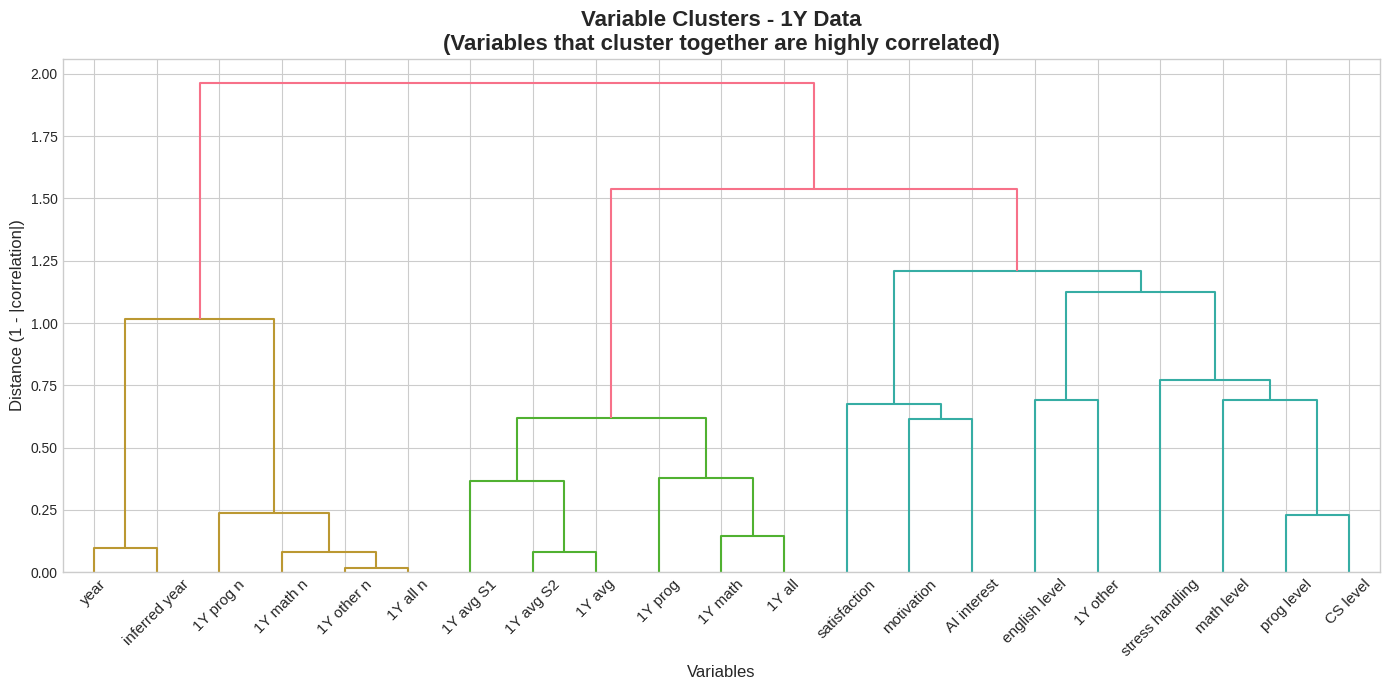

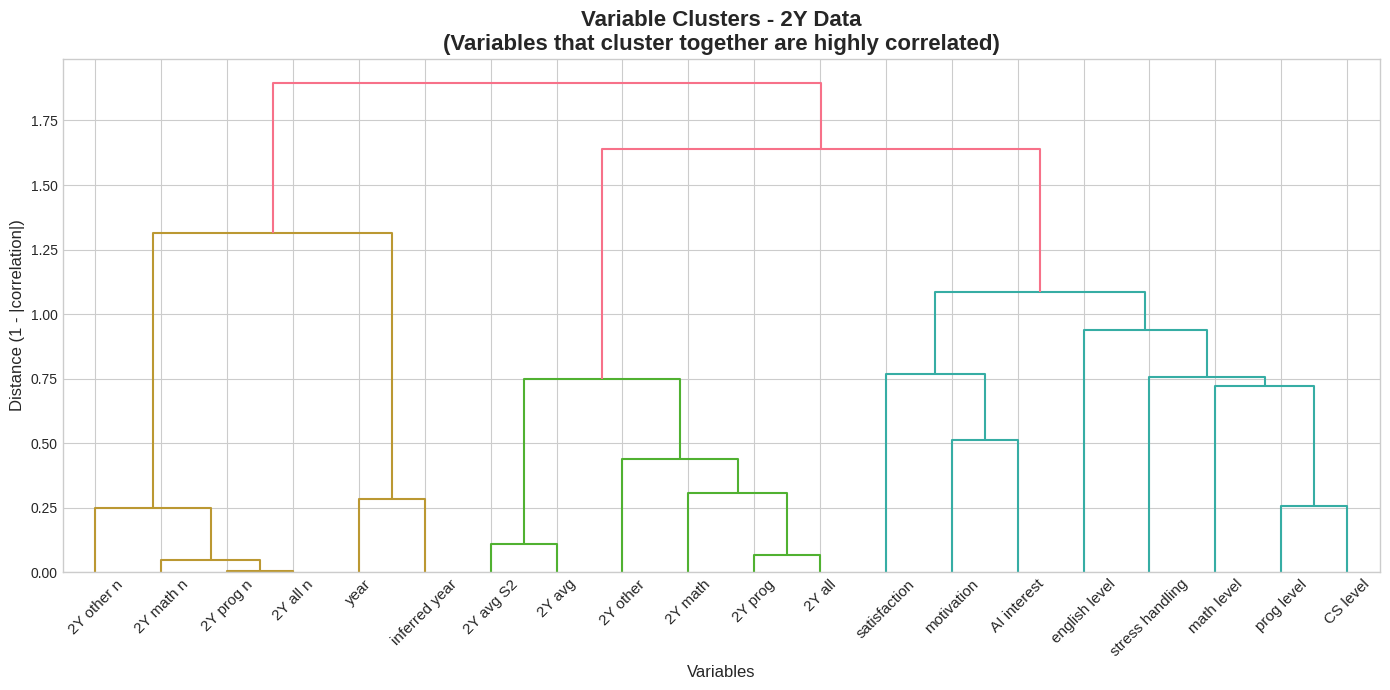

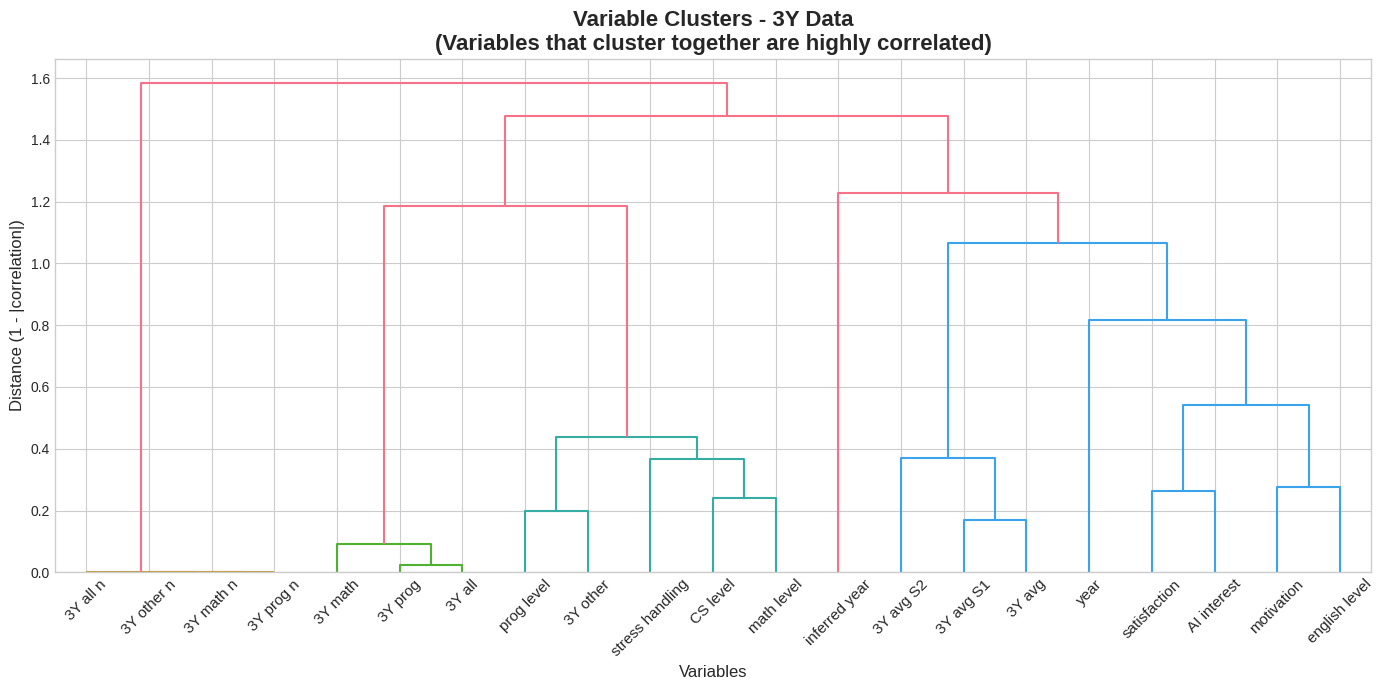

In [8]:
# Identify correlation clusters using hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

def plot_correlation_dendrogram(corr_matrix, short_names, title):
    """Plot dendrogram to visualize variable clusters based on correlation."""
    # Convert correlation to distance (1 - |correlation|)
    distance_matrix = 1 - np.abs(corr_matrix)
    
    # Make a writable copy before modifying
    distance_values = distance_matrix.values.copy().astype(float)
    
    # Replace NaNs (if any) with maximum distance (1.0) so they don't break symmetry checks
    if np.isnan(distance_values).any():
        distance_values = np.where(np.isnan(distance_values), 1.0, distance_values)
    
    # Enforce symmetry (averaging with transpose) to avoid small asymmetries
    distance_values = (distance_values + distance_values.T) / 2.0
    
    # Ensure zero diagonal
    np.fill_diagonal(distance_values, 0.0)
    
    # Now create condensed distance vector for linkage
    condensed_dist = squareform(distance_values)
    linkage_matrix = linkage(condensed_dist, method='ward')
    
    # Use short names for labels
    short_labels = [short_names[c] for c in corr_matrix.columns]
    
    plt.figure(figsize=(14, 7))
    dendrogram(linkage_matrix, labels=short_labels, leaf_rotation=45, leaf_font_size=11)
    plt.title(f'{title}\n(Variables that cluster together are highly correlated)', fontsize=16, fontweight='bold')
    plt.xlabel('Variables', fontsize=12)
    plt.ylabel('Distance (1 - |correlation|)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return linkage_matrix

# Plot dendrograms for each year
print("\nCORRELATION DENDROGRAMS")
print("Variables clustering together share similar correlation patterns\n")

linkage_1y = plot_correlation_dendrogram(pearson_1y, short_names_1y, 'Variable Clusters - 1Y Data')
linkage_2y = plot_correlation_dendrogram(pearson_2y, short_names_2y, 'Variable Clusters - 2Y Data')
linkage_3y = plot_correlation_dendrogram(pearson_3y, short_names_3y, 'Variable Clusters - 3Y Data')

---
# 2. Covariance Matrix

Covariance measures how two variables change together. Unlike correlation, it is not standardized and depends on the scale of the variables.
- Positive covariance: Variables increase together
- Negative covariance: One increases while the other decreases

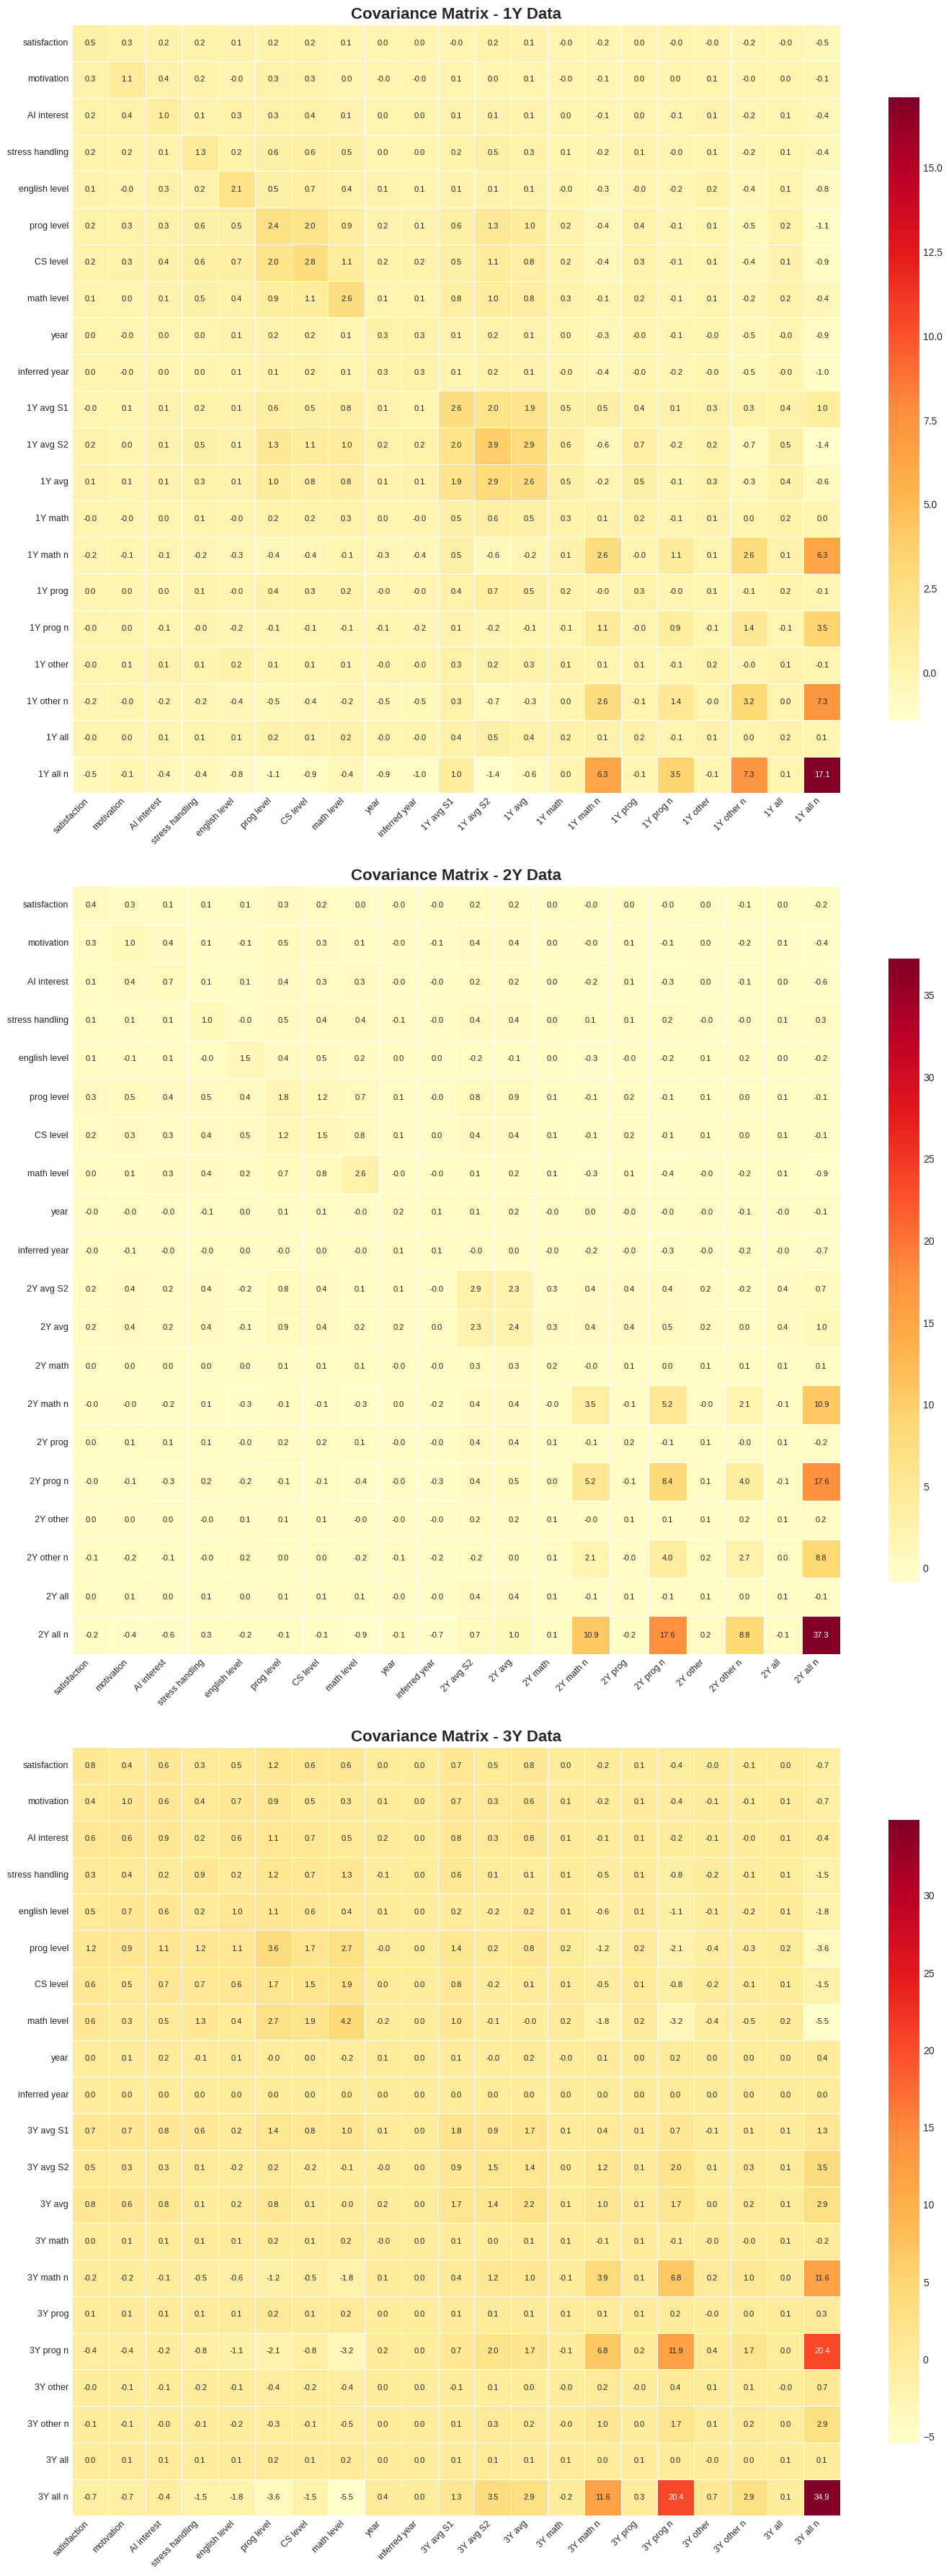

In [9]:
# Covariance Matrices
fig, axes = plt.subplots(3, 1, figsize=(14, 36))

# 1Y Covariance
cov_1y = numeric_1y.cov()
cov_1y_display = cov_1y.copy()
cov_1y_display.index = [short_names_1y[c] for c in cov_1y_display.index]
cov_1y_display.columns = [short_names_1y[c] for c in cov_1y_display.columns]
sns.heatmap(cov_1y_display, annot=True, cmap='YlOrRd', fmt='.1f', 
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('Covariance Matrix - 1Y Data', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

# 2Y Covariance
cov_2y = numeric_2y.cov()
cov_2y_display = cov_2y.copy()
cov_2y_display.index = [short_names_2y[c] for c in cov_2y_display.index]
cov_2y_display.columns = [short_names_2y[c] for c in cov_2y_display.columns]
sns.heatmap(cov_2y_display, annot=True, cmap='YlOrRd', fmt='.1f', 
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('Covariance Matrix - 2Y Data', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

# 3Y Covariance
cov_3y = numeric_3y.cov()
cov_3y_display = cov_3y.copy()
cov_3y_display.index = [short_names_3y[c] for c in cov_3y_display.index]
cov_3y_display.columns = [short_names_3y[c] for c in cov_3y_display.columns]
sns.heatmap(cov_3y_display, annot=True, cmap='YlOrRd', fmt='.1f', 
            ax=axes[2], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[2].set_title('Covariance Matrix - 3Y Data', fontsize=16, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', rotation=0, labelsize=9)
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

In [10]:
# Display covariance statistics
print("Covariance Matrix Statistics (1Y Data)")
print("="*60)
print(f"\nVariance (diagonal elements):")
for col in numeric_1y.columns:
    print(f"  {col}: {cov_1y.loc[col, col]:.4f}")

# Find highest covariances
print(f"\nTop 10 Covariance Pairs (1Y Data):")
cov_pairs = []
for i in range(len(cov_1y.columns)):
    for j in range(i+1, len(cov_1y.columns)):
        cov_pairs.append((cov_1y.columns[i], cov_1y.columns[j], cov_1y.iloc[i, j]))

cov_pairs_sorted = sorted(cov_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]
for col1, col2, cov_val in cov_pairs_sorted:
    print(f"  {col1} & {col2}: {cov_val:.4f}")

Covariance Matrix Statistics (1Y Data)

Variance (diagonal elements):
  rate your satisfaction with the school s program: 0.5360
  your level of motivation for joining ensia: 1.1480
  how much do you like the field of artificial intelligence: 0.9561
  how well do you handle stress and pressure: 1.2679
  in a scale of 1 to 10 how do you rate your level in the following fields 1 english: 2.0724
  2 programming: 2.3660
  3 computer science: 2.8277
  4 mathematics: 2.5551
  year_ordinal: 0.3427
  inferred_year_from_grades: 0.3258
  1y average s1: 2.6011
  1y average s2: 3.9135
  1y average: 2.6058
  1Y_math_avg: 0.2884
  1Y_math_n: 2.5694
  1Y_programming_avg: 0.3052
  1Y_programming_n: 0.9114
  1Y_other_avg: 0.2181
  1Y_other_n: 3.2396
  1Y_all_modules_avg: 0.1664
  1Y_all_modules_n: 17.1001

Top 10 Covariance Pairs (1Y Data):
  1Y_other_n & 1Y_all_modules_n: 7.3219
  1Y_math_n & 1Y_all_modules_n: 6.3121
  1Y_programming_n & 1Y_all_modules_n: 3.4662
  1y average s2 & 1y average: 2.9290
  

### 2.1 Covariance Interpretation

**Key insight**: Covariance values are scale-dependent. High covariance pairs indicate variables that vary together, but the magnitude depends on their scales. Use correlation for standardized comparison.

---
# 4. Mutual Information (Non-linear Dependence)

Mutual Information (MI) measures the amount of information obtained about one variable by observing another. Unlike correlation, MI can capture **non-linear dependencies**.
- MI = 0: Variables are independent
- Higher MI: Stronger dependence (linear or non-linear)

In [11]:
def compute_mutual_info_matrix(df):
    """
    Compute pairwise mutual information matrix for numeric columns (excluding record_id).
    """
    numeric_df = df.select_dtypes(include=[np.number])
    # Drop record_id if present
    cols_to_drop = [col for col in numeric_df.columns if 'record_id' in col.lower()]
    numeric_df = numeric_df.drop(columns=cols_to_drop, errors='ignore').dropna()
    
    cols = numeric_df.columns
    n_cols = len(cols)
    mi_matrix = np.zeros((n_cols, n_cols))
    
    for i, col1 in enumerate(cols):
        for j, col2 in enumerate(cols):
            if i == j:
                mi_matrix[i, j] = 1.0  # MI with itself (normalized)
            elif i < j:
                # Compute MI
                mi = mutual_info_regression(numeric_df[[col1]], numeric_df[col2], random_state=42)[0]
                # Normalize by max possible MI for comparability
                mi_matrix[i, j] = mi
                mi_matrix[j, i] = mi
    
    return pd.DataFrame(mi_matrix, index=cols, columns=cols)

print("Computing Mutual Information Matrices (this may take a moment)...")

Computing Mutual Information Matrices (this may take a moment)...


Mutual Information Matrices computed!


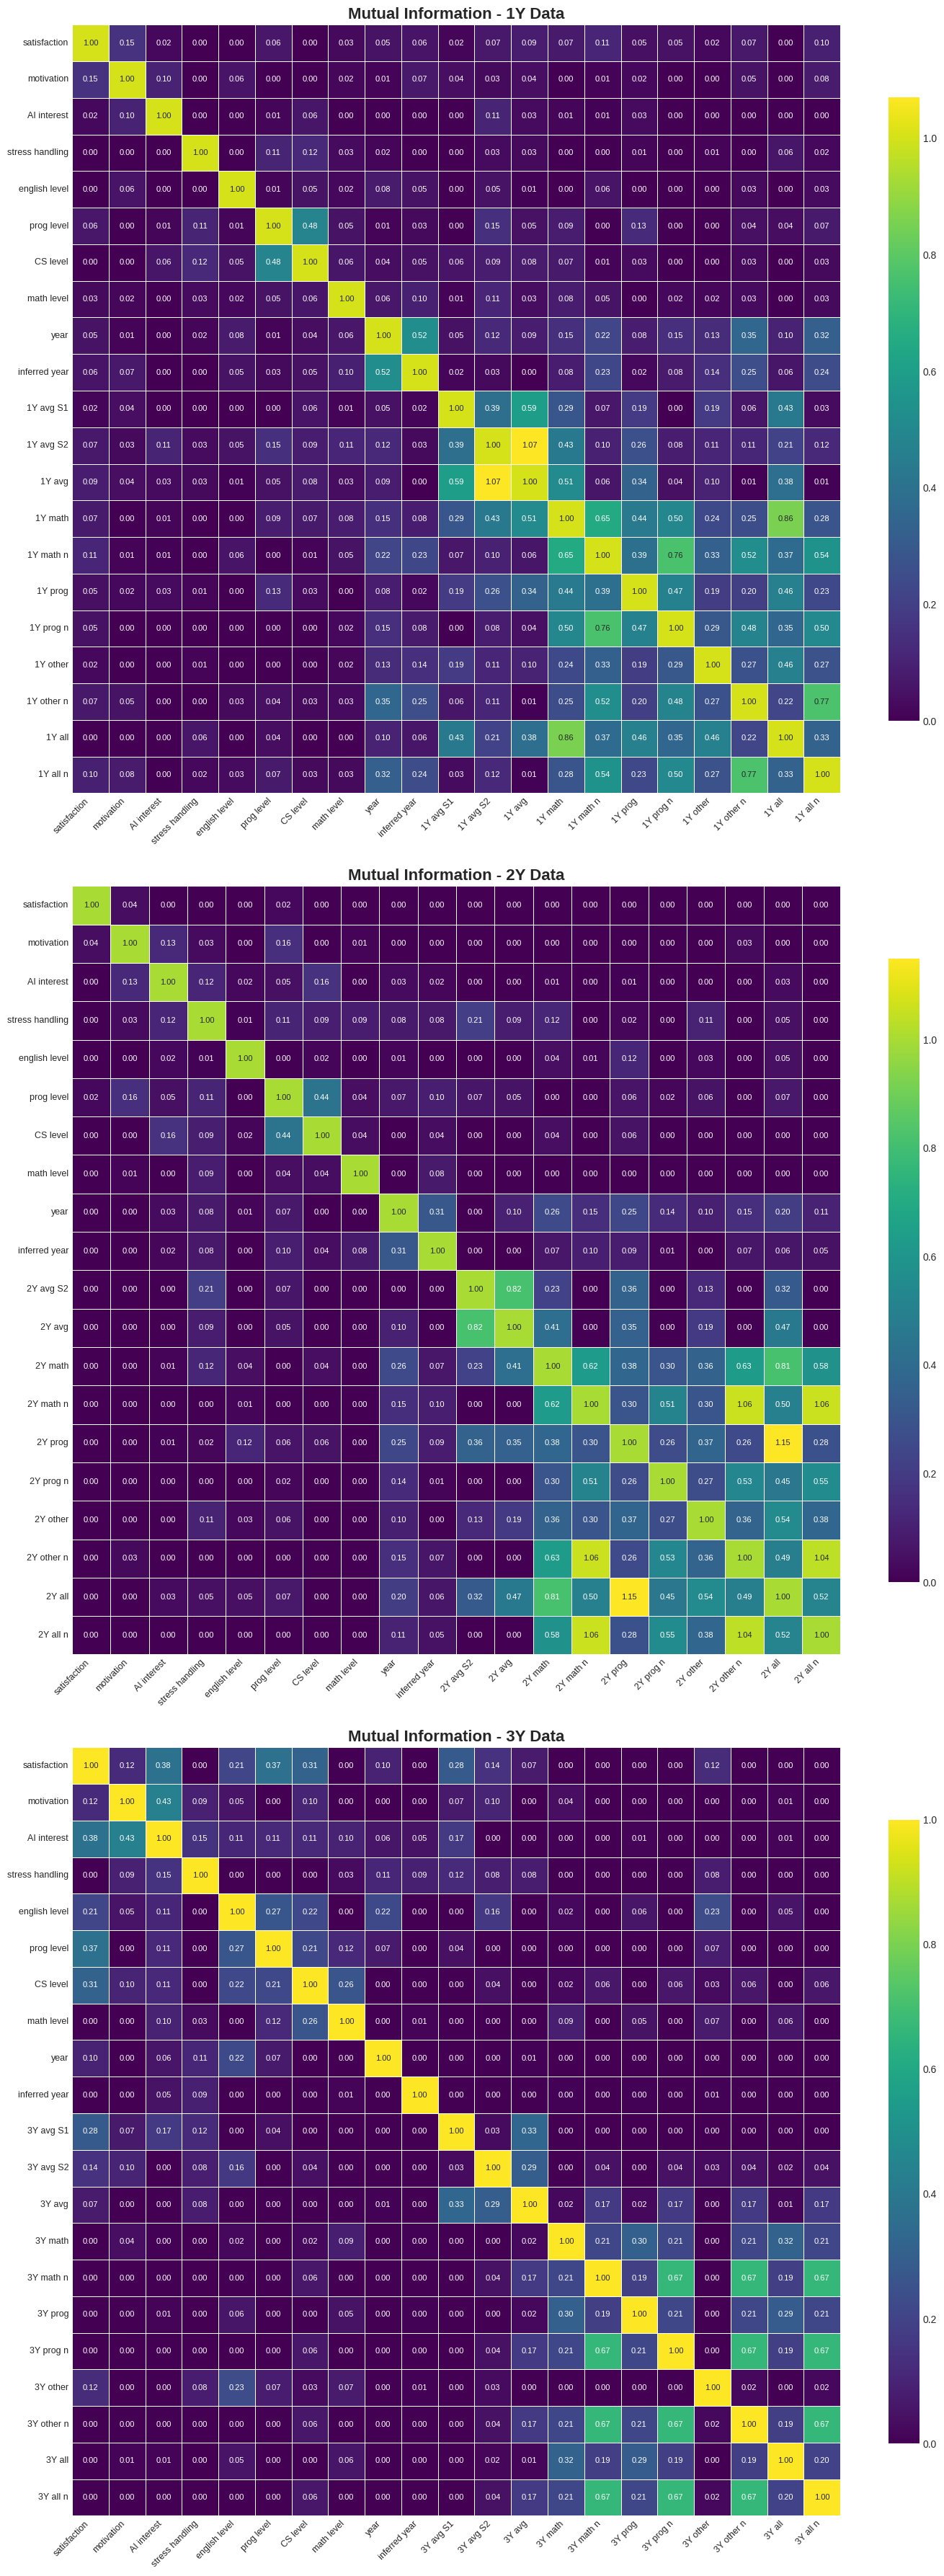

In [12]:
# Compute Mutual Information Matrices
mi_1y = compute_mutual_info_matrix(numeric_1y)
mi_2y = compute_mutual_info_matrix(numeric_2y)
mi_3y = compute_mutual_info_matrix(numeric_3y)

print("Mutual Information Matrices computed!")

# Visualize MI matrices with short names
fig, axes = plt.subplots(3, 1, figsize=(14, 36))

mi_1y_display = mi_1y.copy()
mi_1y_display.index = [short_names_1y[c] for c in mi_1y_display.index]
mi_1y_display.columns = [short_names_1y[c] for c in mi_1y_display.columns]
sns.heatmap(mi_1y_display, annot=True, cmap='viridis', fmt='.2f', 
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('Mutual Information - 1Y Data', fontsize=16, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=9)
axes[0].tick_params(axis='y', rotation=0, labelsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')

mi_2y_display = mi_2y.copy()
mi_2y_display.index = [short_names_2y[c] for c in mi_2y_display.index]
mi_2y_display.columns = [short_names_2y[c] for c in mi_2y_display.columns]
sns.heatmap(mi_2y_display, annot=True, cmap='viridis', fmt='.2f', 
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('Mutual Information - 2Y Data', fontsize=16, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=9)
axes[1].tick_params(axis='y', rotation=0, labelsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')

mi_3y_display = mi_3y.copy()
mi_3y_display.index = [short_names_3y[c] for c in mi_3y_display.index]
mi_3y_display.columns = [short_names_3y[c] for c in mi_3y_display.columns]
sns.heatmap(mi_3y_display, annot=True, cmap='viridis', fmt='.2f', 
            ax=axes[2], linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8}, square=True)
axes[2].set_title('Mutual Information - 3Y Data', fontsize=16, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=9)
axes[2].tick_params(axis='y', rotation=0, labelsize=9)
axes[2].set_xticklabels(axes[2].get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

In [13]:
# Compare MI with Correlation to find non-linear relationships
print("Mutual Information vs Pearson Correlation (1Y Data)")
print("="*70)
print("High MI but low correlation suggests NON-LINEAR relationship\n")

# Flatten matrices for comparison
mi_pairs = []
for i in range(len(mi_1y.columns)):
    for j in range(i+1, len(mi_1y.columns)):
        col1, col2 = mi_1y.columns[i], mi_1y.columns[j]
        mi_val = mi_1y.iloc[i, j]
        corr_val = abs(pearson_1y.iloc[i, j])
        # Non-linear indicator: high MI but relatively low correlation
        nonlinear_score = mi_val - corr_val if mi_val > 0.1 else 0
        mi_pairs.append((col1, col2, mi_val, corr_val, nonlinear_score))

# Sort by non-linear score
mi_pairs_sorted = sorted(mi_pairs, key=lambda x: -x[4])[:10]

print(f"{'Variable Pair':<50} {'MI':>8} {'|Corr|':>8} {'NL Score':>10}")
print("-"*80)
for col1, col2, mi, corr, nl in mi_pairs_sorted:
    indicator = "*" if nl > 0.1 else ""
    print(f"{col1[:22]} vs {col2[:22]:<22} {mi:>8.3f} {corr:>8.3f} {nl:>10.3f} {indicator}")

print("\n* = Potential non-linear relationship")

Mutual Information vs Pearson Correlation (1Y Data)
High MI but low correlation suggests NON-LINEAR relationship

Variable Pair                                            MI   |Corr|   NL Score
--------------------------------------------------------------------------------
1Y_math_avg vs 1Y_math_n                 0.649    0.113      0.536 *
1Y_programming_avg vs 1Y_programming_n          0.467    0.077      0.390 *
1Y_math_n vs 1Y_programming_avg        0.389    0.020      0.369 *
1Y_math_avg vs 1Y_programming_n          0.495    0.150      0.345 *
1Y_all_modules_avg vs 1Y_all_modules_n          0.331    0.044      0.287 *
1Y_math_avg vs 1Y_all_modules_n          0.278    0.019      0.258 *
1Y_other_avg vs 1Y_all_modules_n          0.268    0.040      0.228 *
1Y_math_avg vs 1Y_other_n                0.249    0.023      0.227 *
1Y_math_n vs 1Y_other_avg              0.326    0.100      0.225 *
1Y_other_avg vs 1Y_other_n                0.266    0.045      0.221 *

* = Potential non-line

### 4.1 Mutual Information Interpretation

**Non-linear relationships detected**: Pairs with high MI but low correlation likely have non-linear dependencies that correlation cannot capture. These are candidates for:
- Polynomial regression
- Non-linear transformations
- Tree-based models

---
# 5. Principal Component Analysis (PCA)

PCA is a dimensionality reduction technique that transforms correlated variables into a smaller set of uncorrelated **principal components**.
- Each component captures a portion of the total variance
- Helps identify the main sources of variation in the data
- Useful for visualization and feature selection

In [14]:
def perform_pca_analysis(data, year_label):
    """
    Perform comprehensive PCA analysis on numeric data.
    """
    # Prepare data - exclude record_id
    numeric_data = data.select_dtypes(include=[np.number])
    cols_to_drop = [col for col in numeric_data.columns if 'record_id' in col.lower()]
    numeric_data = numeric_data.drop(columns=cols_to_drop, errors='ignore').dropna()
    feature_names = numeric_data.columns.tolist()
    
    # Standardize the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(numeric_data)
    
    # Apply PCA
    pca = PCA()
    pca_result = pca.fit_transform(data_scaled)
    
    return pca, pca_result, feature_names, data_scaled

# Perform PCA for all years
pca_1y, pca_result_1y, features_1y, scaled_1y = perform_pca_analysis(data_1y, '1Y')
pca_2y, pca_result_2y, features_2y, scaled_2y = perform_pca_analysis(data_2y, '2Y')
pca_3y, pca_result_3y, features_3y, scaled_3y = perform_pca_analysis(data_3y, '3Y')

print("PCA Analysis completed for all years!")

PCA Analysis completed for all years!


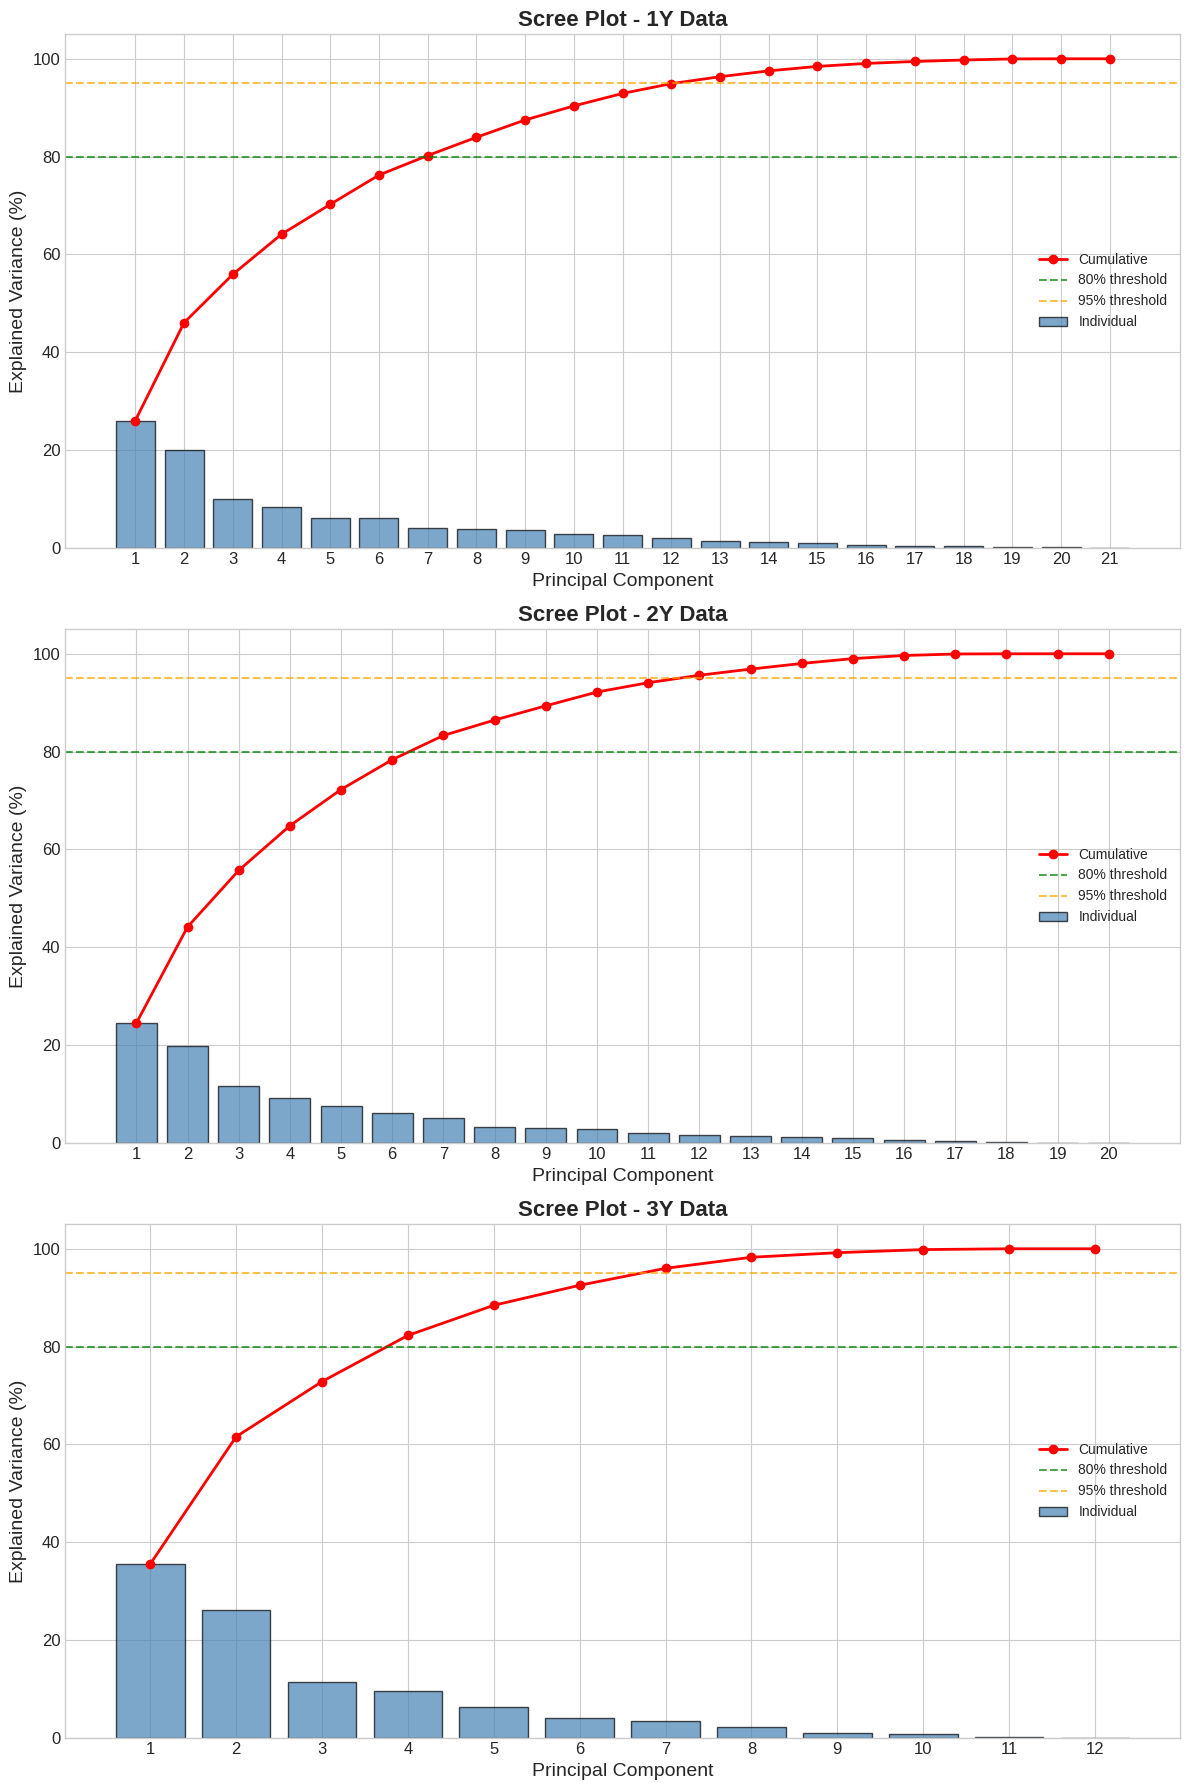

In [15]:
# Scree Plots - Explained Variance
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for ax, pca, label in [(axes[0], pca_1y, '1Y'), (axes[1], pca_2y, '2Y'), (axes[2], pca_3y, '3Y')]:
    n_components = len(pca.explained_variance_ratio_)
    x_vals = range(1, n_components + 1)
    
    # Bar plot for individual variance
    bars = ax.bar(x_vals, pca.explained_variance_ratio_ * 100, 
                  alpha=0.7, color='steelblue', edgecolor='black', label='Individual')
    
    # Line plot for cumulative variance
    cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
    ax.plot(x_vals, cumulative, 'ro-', linewidth=2, markersize=6, label='Cumulative')
    
    # Add 80% and 95% threshold lines
    ax.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% threshold')
    ax.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')
    
    ax.set_xlabel('Principal Component', fontsize=14)
    ax.set_ylabel('Explained Variance (%)', fontsize=14)
    ax.set_title(f'Scree Plot - {label} Data', fontsize=16, fontweight='bold')
    ax.legend(loc='center right', fontsize=10)
    ax.set_xticks(x_vals)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [16]:
# Explained Variance Summary
print("PCA Explained Variance Summary")
print("="*80)

for pca, label in [(pca_1y, '1Y'), (pca_2y, '2Y'), (pca_3y, '3Y')]:
    print(f"\n{label} Data:")
    print("-"*60)
    cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
    
    print(f"{'PC':<6} {'Variance %':>12} {'Cumulative %':>15}")
    for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_ * 100, cumulative)):
        if i < 5 or cum <= 95:  # Show first 5 or until 95% explained
            print(f"PC{i+1:<4} {var:>12.2f} {cum:>15.2f}")
    
    # Find components needed for 80% and 95%
    n_80 = np.argmax(cumulative >= 80) + 1
    n_95 = np.argmax(cumulative >= 95) + 1
    print(f"\n  -> Components for 80% variance: {n_80}")
    print(f"  -> Components for 95% variance: {n_95}")

PCA Explained Variance Summary

1Y Data:
------------------------------------------------------------
PC       Variance %    Cumulative %
PC1           25.99           25.99
PC2           20.02           46.00
PC3            9.89           55.89
PC4            8.21           64.10
PC5            6.11           70.22
PC6            5.99           76.21
PC7            3.99           80.20
PC8            3.74           83.93
PC9            3.55           87.48
PC10           2.88           90.36
PC11           2.55           92.90
PC12           2.01           94.91

  -> Components for 80% variance: 7
  -> Components for 95% variance: 13

2Y Data:
------------------------------------------------------------
PC       Variance %    Cumulative %
PC1           24.43           24.43
PC2           19.68           44.11
PC3           11.57           55.67
PC4            9.14           64.82
PC5            7.42           72.23
PC6            6.10           78.33
PC7            4.96           83.

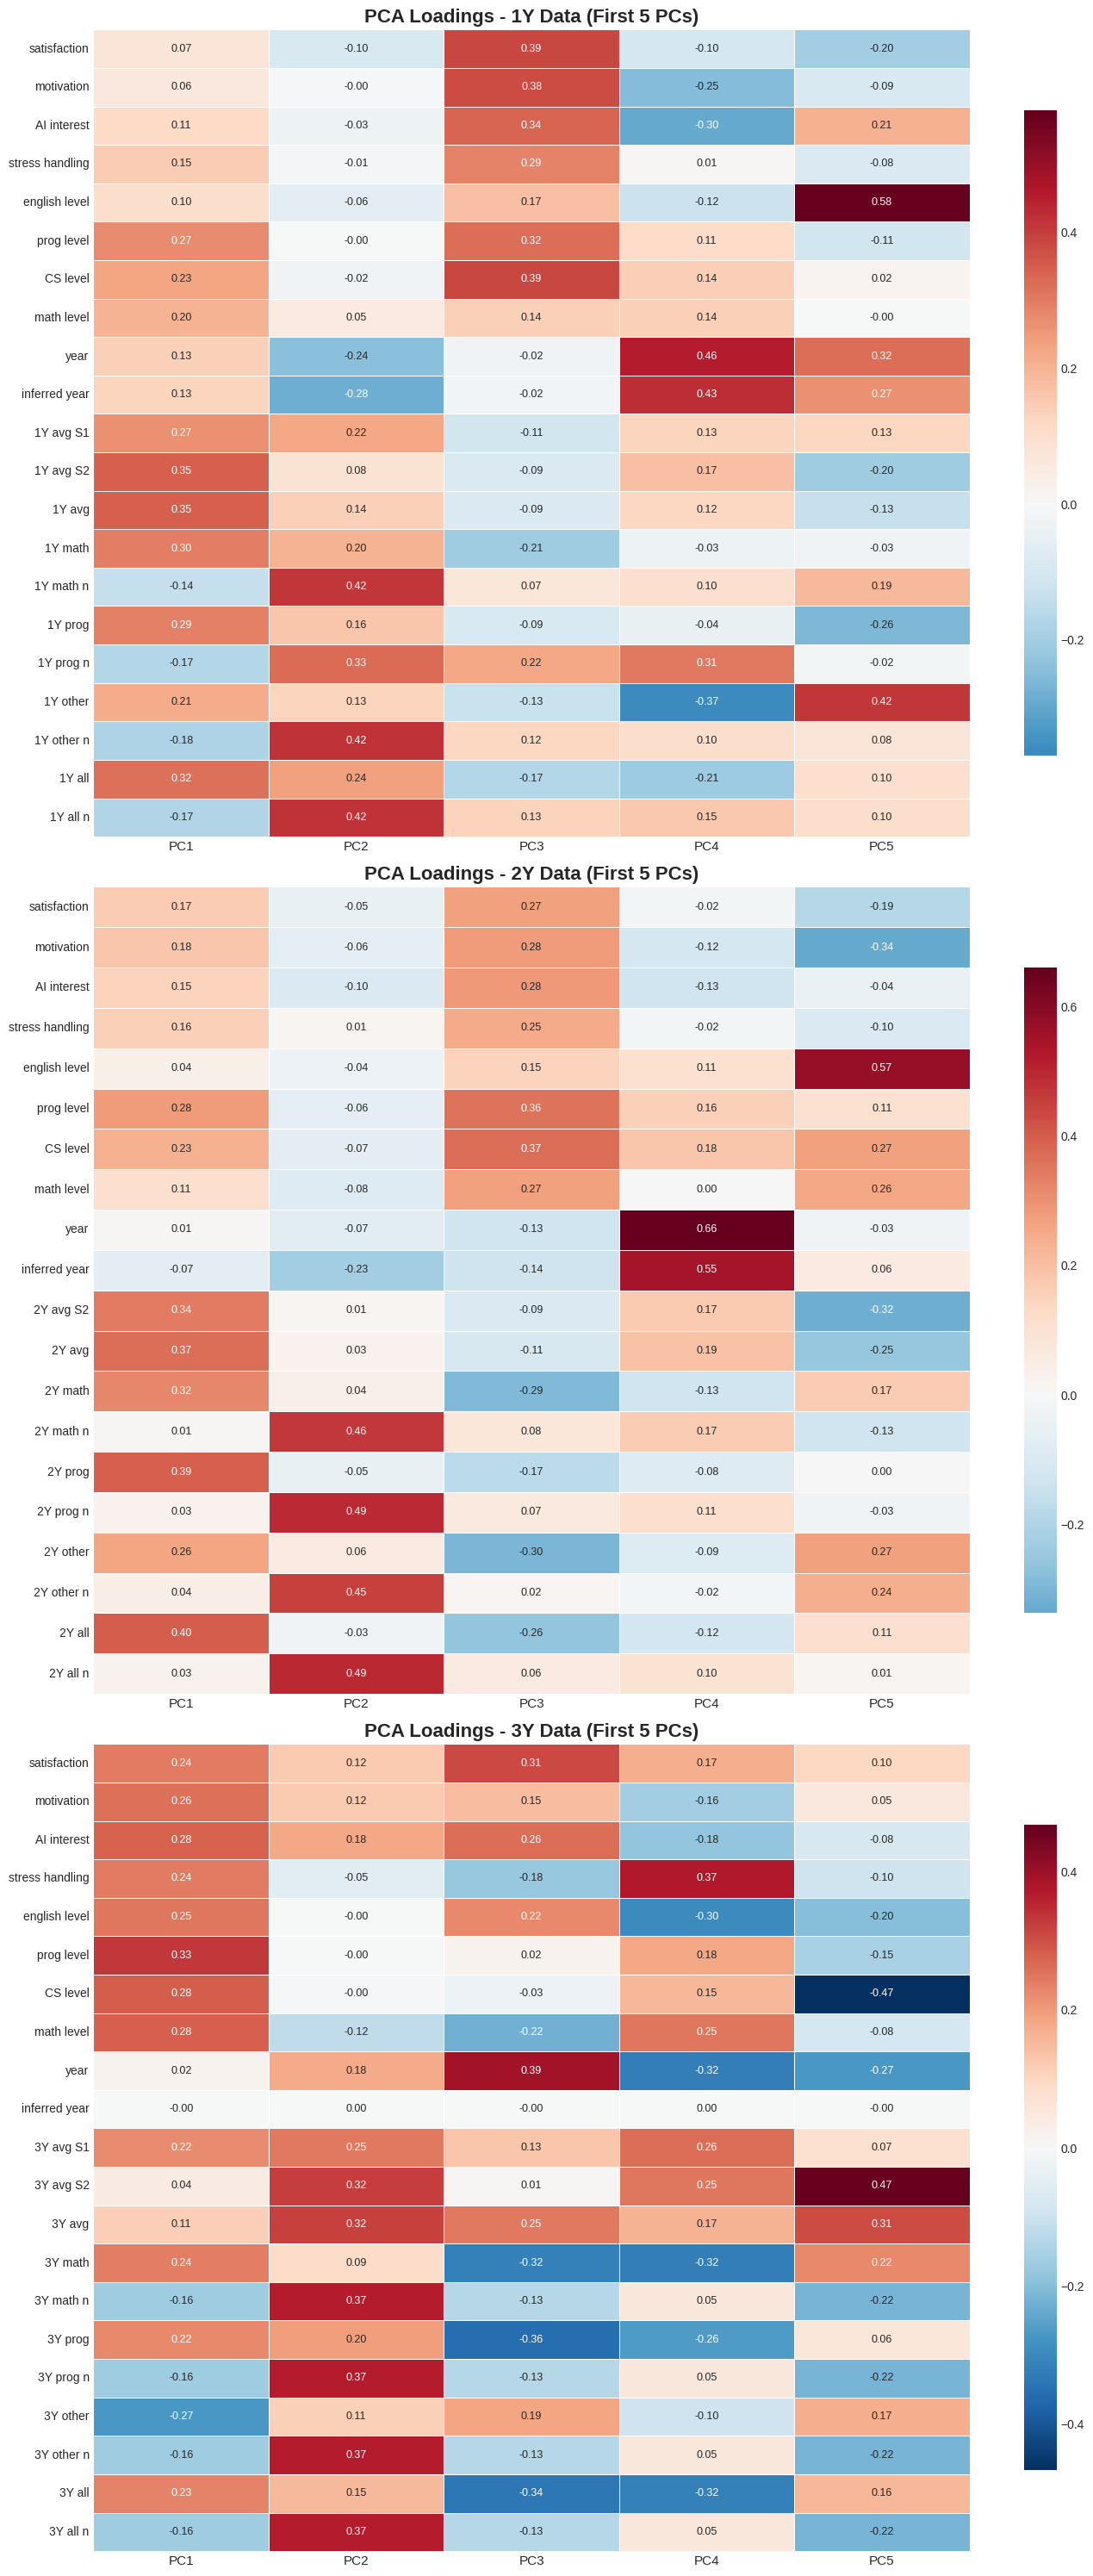

In [17]:
# PCA Loadings (Component Weights)
fig, axes = plt.subplots(3, 1, figsize=(14, 30))

for ax, pca, features, label, short_names in [(axes[0], pca_1y, features_1y, '1Y', short_names_1y), 
                                               (axes[1], pca_2y, features_2y, '2Y', short_names_2y), 
                                               (axes[2], pca_3y, features_3y, '3Y', short_names_3y)]:
    # Get loadings for first 5 components
    n_show = min(5, len(pca.components_))
    short_feature_names = [short_names[f] for f in features]
    loadings = pd.DataFrame(
        pca.components_[:n_show].T,
        columns=[f'PC{i+1}' for i in range(n_show)],
        index=short_feature_names
    )
    
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', 
                ax=ax, linewidths=0.5, annot_kws={'size': 9},
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'PCA Loadings - {label} Data (First 5 PCs)', fontsize=16, fontweight='bold')
    ax.tick_params(axis='x', rotation=0, labelsize=11)
    ax.tick_params(axis='y', rotation=0, labelsize=10)

plt.tight_layout()
plt.show()

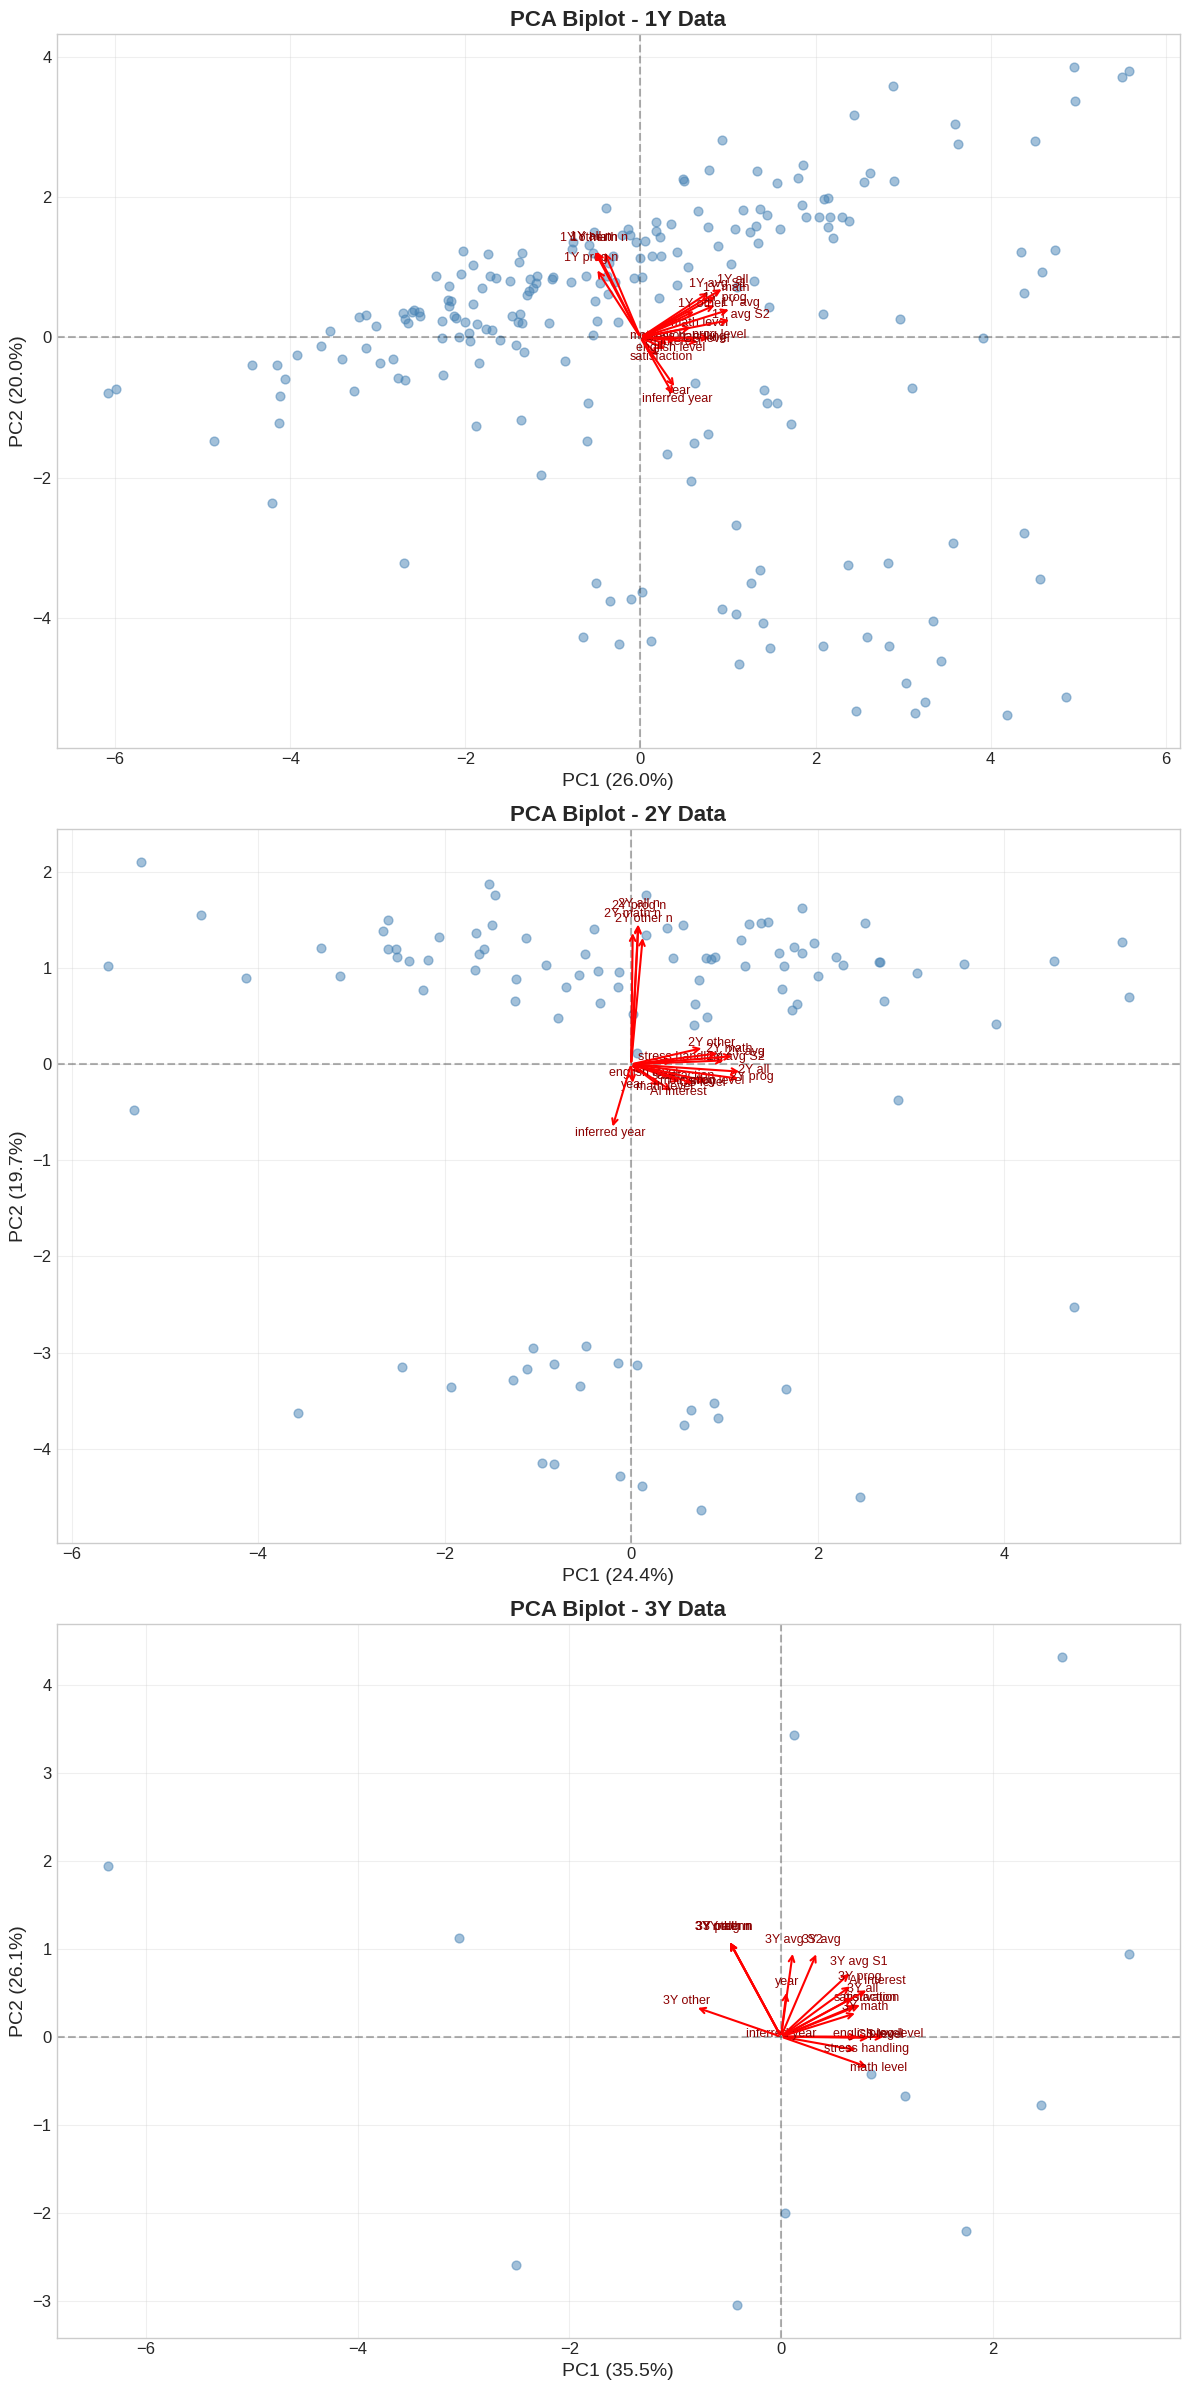

In [18]:
# PCA Biplot - PC1 vs PC2
fig, axes = plt.subplots(3, 1, figsize=(12, 24))

for ax, pca, pca_result, features, label, short_names in [(axes[0], pca_1y, pca_result_1y, features_1y, '1Y', short_names_1y), 
                                                           (axes[1], pca_2y, pca_result_2y, features_2y, '2Y', short_names_2y), 
                                                           (axes[2], pca_3y, pca_result_3y, features_3y, '3Y', short_names_3y)]:
    # Scatter plot of observations
    ax.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, s=40, c='steelblue')
    
    # Add loading vectors
    loadings = pca.components_[:2].T
    scale = 3  # Scale factor for visibility
    
    for i, feature in enumerate(features):
        ax.annotate('', xy=(loadings[i, 0]*scale, loadings[i, 1]*scale), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
        # Use short name for label
        short_label = short_names[feature]
        ax.text(loadings[i, 0]*scale*1.1, loadings[i, 1]*scale*1.1, 
                short_label, fontsize=9, ha='center', color='darkred')
    
    var1, var2 = pca.explained_variance_ratio_[:2] * 100
    ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=14)
    ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=14)
    ax.set_title(f'PCA Biplot - {label} Data', fontsize=16, fontweight='bold')
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

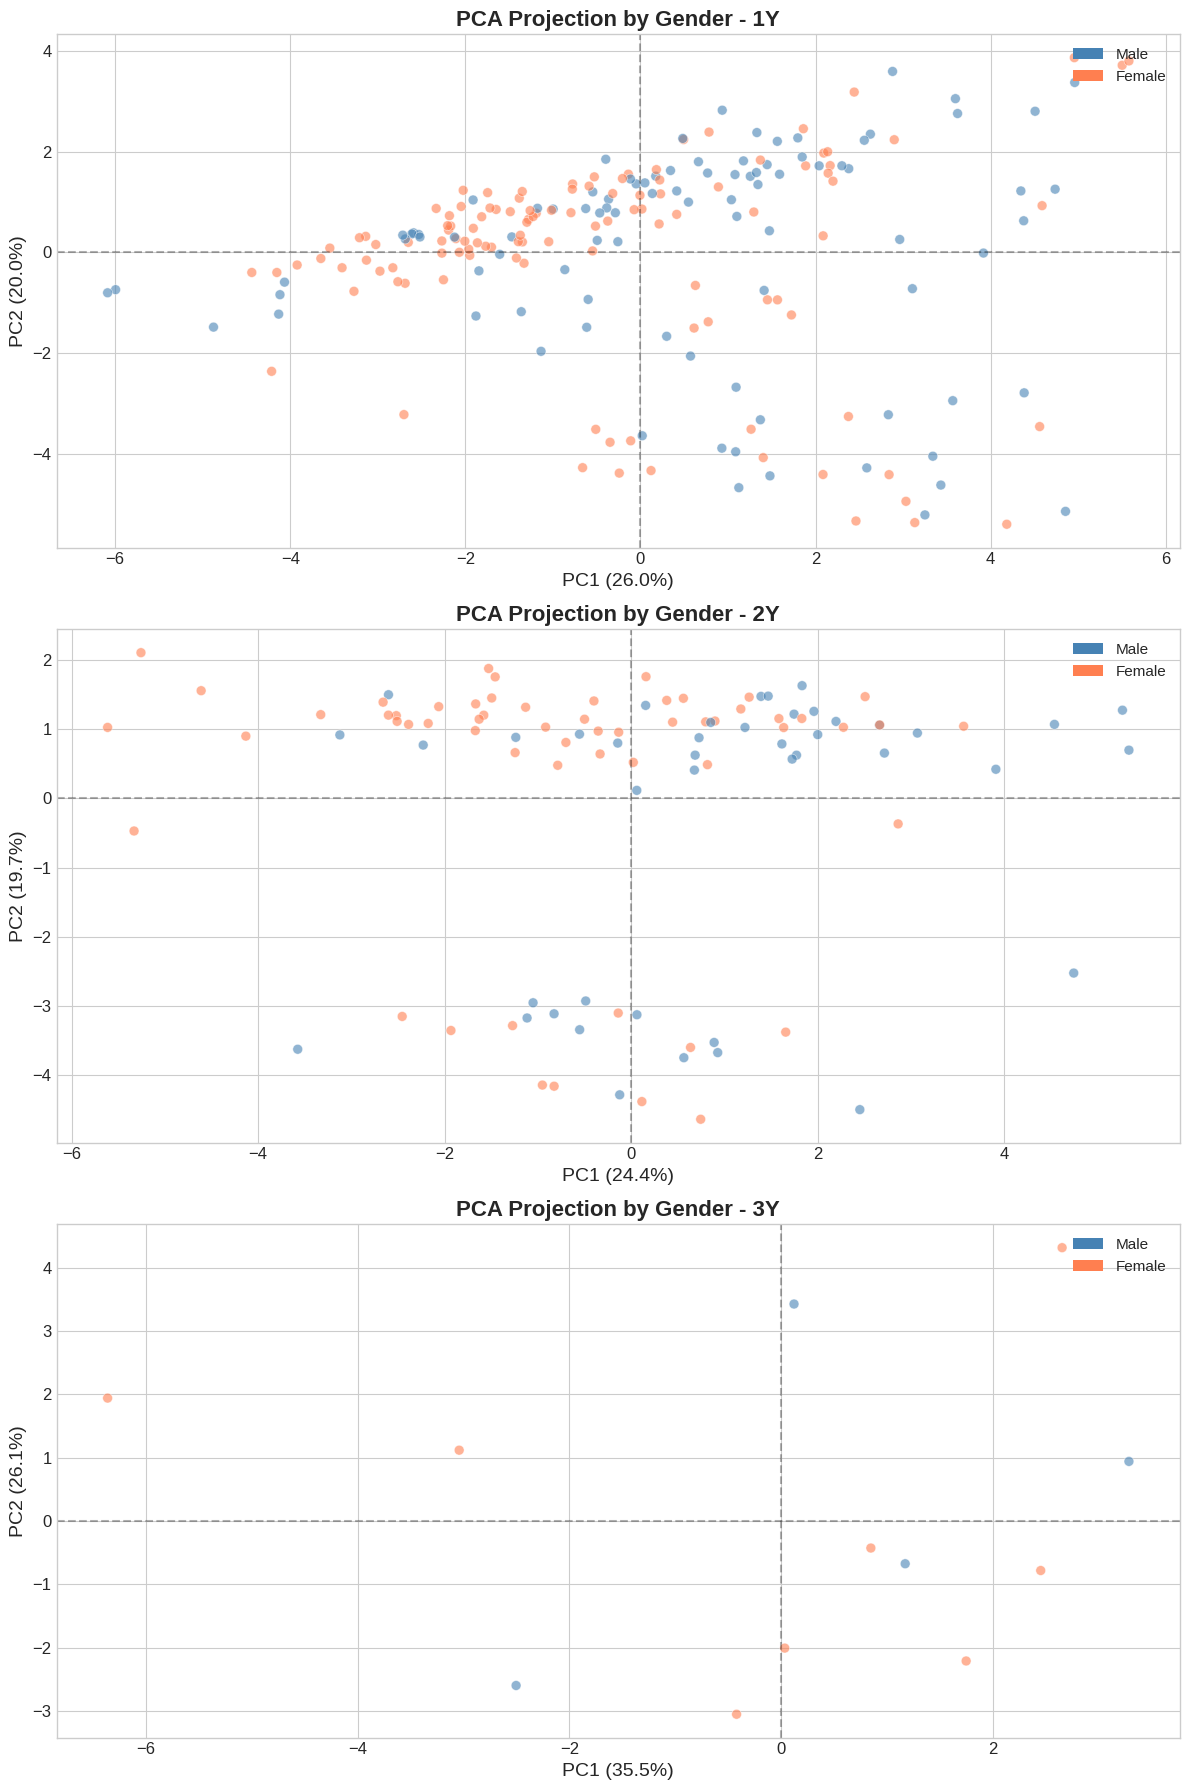

In [19]:
# PCA Projection colored by Gender (if available)
if 'what is your gender' in data_1y.columns:
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    
    # Get gender labels for each dataset (aligned with PCA results)
    for ax, pca, pca_result, data, label in [(axes[0], pca_1y, pca_result_1y, data_1y, '1Y'), 
                                               (axes[1], pca_2y, pca_result_2y, data_2y, '2Y'), 
                                               (axes[2], pca_3y, pca_result_3y, data_3y, '3Y')]:
        # Need to align gender with the rows used in PCA (excluding record_id)
        numeric_data = data.select_dtypes(include=[np.number])
        cols_to_drop = [col for col in numeric_data.columns if 'record_id' in col.lower()]
        numeric_data = numeric_data.drop(columns=cols_to_drop, errors='ignore').dropna()
        gender_aligned = data.loc[numeric_data.index, 'what is your gender']
        
        colors = gender_aligned.map({'Male': 'steelblue', 'Female': 'coral'}).fillna('gray')
        
        scatter = ax.scatter(pca_result[:, 0], pca_result[:, 1], 
                            c=colors, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)
        
        var1, var2 = pca.explained_variance_ratio_[:2] * 100
        ax.set_xlabel(f'PC1 ({var1:.1f}%)', fontsize=14)
        ax.set_ylabel(f'PC2 ({var2:.1f}%)', fontsize=14)
        ax.set_title(f'PCA Projection by Gender - {label}', fontsize=16, fontweight='bold')
        ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
        ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
        ax.tick_params(labelsize=12)
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='steelblue', label='Male'),
                          Patch(facecolor='coral', label='Female')]
        ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()

### 5.1 PCA Interpretation

Use the following cell to extract **meaningful variable groups** based on PCA loadings.

In [20]:
# Interpret PCA Components - What does each PC represent?
def interpret_pca_components(pca, features, n_components=3, threshold=0.3):
    """Identify dominant features in each principal component."""
    print("\nPCA COMPONENT INTERPRETATION")
    print("="*80)
    print(f"Showing features with |loading| >= {threshold}\n")
    
    interpretations = {}
    for pc_idx in range(min(n_components, len(pca.components_))):
        loadings = pd.Series(pca.components_[pc_idx], index=features)
        var_explained = pca.explained_variance_ratio_[pc_idx] * 100
        
        # Get dominant features
        dominant = loadings[loadings.abs() >= threshold].sort_values(key=abs, ascending=False)
        
        print(f"\nPC{pc_idx+1} ({var_explained:.1f}% variance):")
        print("-"*50)
        
        positive_features = dominant[dominant > 0]
        negative_features = dominant[dominant < 0]
        
        if len(positive_features) > 0:
            print("  [+] Positive contributors:")
            for feat, val in positive_features.items():
                print(f"      {feat}: +{val:.3f}")
        
        if len(negative_features) > 0:
            print("  [-] Negative contributors:")
            for feat, val in negative_features.items():
                print(f"      {feat}: {val:.3f}")
        
        interpretations[f'PC{pc_idx+1}'] = {'positive': positive_features, 'negative': negative_features}
    
    return interpretations

# Interpret components for each year
print("\n" + "="*80)
print("\n1Y DATA INTERPRETATION:")
interpret_1y = interpret_pca_components(pca_1y, features_1y)

print("\n" + "="*80)
print("\n2Y DATA INTERPRETATION:")
interpret_2y = interpret_pca_components(pca_2y, features_2y)

print("\n" + "="*80)
print("\n3Y DATA INTERPRETATION:")
interpret_3y = interpret_pca_components(pca_3y, features_3y)



1Y DATA INTERPRETATION:

PCA COMPONENT INTERPRETATION
Showing features with |loading| >= 0.3


PC1 (26.0% variance):
--------------------------------------------------
  [+] Positive contributors:
      1y average s2: +0.348
      1y average: +0.347
      1Y_all_modules_avg: +0.318

PC2 (20.0% variance):
--------------------------------------------------
  [+] Positive contributors:
      1Y_all_modules_n: +0.420
      1Y_other_n: +0.419
      1Y_math_n: +0.416
      1Y_programming_n: +0.330

PC3 (9.9% variance):
--------------------------------------------------
  [+] Positive contributors:
      rate your satisfaction with the school s program: +0.387
      3 computer science: +0.386
      your level of motivation for joining ensia: +0.376
      how much do you like the field of artificial intelligence: +0.336
      2 programming: +0.323


2Y DATA INTERPRETATION:

PCA COMPONENT INTERPRETATION
Showing features with |loading| >= 0.3


PC1 (24.4% variance):
---------------------------

---
# 6. Summary & Key Observations

This section summarizes the key findings from the multivariate analysis to guide further focused analysis.

In [21]:
# Generate Summary Report
print("="*80)
print("MULTIVARIATE ANALYSIS SUMMARY REPORT")
print("="*80)

# 1. Strongest Correlations
print("\n1. STRONGEST CORRELATIONS (1Y Data - Pearson)")
print("-"*60)
corr_pairs_1y = []
for i in range(len(pearson_1y.columns)):
    for j in range(i+1, len(pearson_1y.columns)):
        corr_pairs_1y.append((pearson_1y.columns[i], pearson_1y.columns[j], pearson_1y.iloc[i, j]))

top_corr = sorted(corr_pairs_1y, key=lambda x: abs(x[2]), reverse=True)[:5]
for col1, col2, corr in top_corr:
    print(f"  * {col1} <-> {col2}: r = {corr:.3f}")

# 2. PCA Summary
print("\n2. PCA DIMENSIONALITY REDUCTION")
print("-"*60)
for pca, label in [(pca_1y, '1Y'), (pca_2y, '2Y'), (pca_3y, '3Y')]:
    cumulative = np.cumsum(pca.explained_variance_ratio_) * 100
    n_80 = np.argmax(cumulative >= 80) + 1
    print(f"  * {label}: {n_80} components explain 80% variance (PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%)")

# 3. Key Features from PCA
print("\n3. DOMINANT FEATURES IN PC1 (1Y Data)")
print("-"*60)
pc1_loadings = pd.Series(pca_1y.components_[0], index=features_1y)
top_features = pc1_loadings.abs().sort_values(ascending=False)[:5]
for feat, loading in top_features.items():
    direction = "+" if pc1_loadings[feat] > 0 else "-"
    print(f"  * {feat}: {direction}{abs(loading):.3f}")

print("\n" + "="*80)
print("General multivariate analysis complete!")
print("Next: Select meaningful variable subsets for focused analysis")
print("="*80)

MULTIVARIATE ANALYSIS SUMMARY REPORT

1. STRONGEST CORRELATIONS (1Y Data - Pearson)
------------------------------------------------------------
  * 1Y_other_n <-> 1Y_all_modules_n: r = 0.984
  * 1Y_math_n <-> 1Y_all_modules_n: r = 0.952
  * 1y average s2 <-> 1y average: r = 0.917
  * 1Y_math_n <-> 1Y_other_n: r = 0.913
  * year_ordinal <-> inferred_year_from_grades: r = 0.903

2. PCA DIMENSIONALITY REDUCTION
------------------------------------------------------------
  * 1Y: 7 components explain 80% variance (PC1 = 26.0%)
  * 2Y: 7 components explain 80% variance (PC1 = 24.4%)
  * 3Y: 4 components explain 80% variance (PC1 = 35.5%)

3. DOMINANT FEATURES IN PC1 (1Y Data)
------------------------------------------------------------
  * 1y average s2: +0.348
  * 1y average: +0.347
  * 1Y_all_modules_avg: +0.318
  * 1Y_math_avg: +0.296
  * 1Y_programming_avg: +0.292

General multivariate analysis complete!
Next: Select meaningful variable subsets for focused analysis


---
# 6. Meaningful Subset Selection

Based on the multivariate analysis, we identify **meaningful variable subsets** for focused analysis. These subsets are selected based on:
1. **High correlation clusters** - Variables that move together
2. **PCA loadings** - Variables that contribute to the same principal components
3. **Mutual information** - Variables with strong dependencies (linear or non-linear)

In [22]:
# Automatically identify meaningful variable subsets
def identify_variable_subsets(corr_matrix, pca, features, mi_matrix):
    """
    Identify meaningful variable subsets based on multiple criteria.
    """
    subsets = {}
    
    # 1. Academic Performance Cluster (high correlation with averages)
    avg_cols = [col for col in features if 'avg' in col.lower() or 'average' in col.lower()]
    if avg_cols:
        subsets['Academic Performance'] = avg_cols
    
    # 2. PC1 Dominant Features (top contributors to main variance)
    pc1_loadings = pd.Series(pca.components_[0], index=features)
    pc1_dominant = pc1_loadings[pc1_loadings.abs() >= 0.3].index.tolist()
    if pc1_dominant:
        subsets['PC1 Dominant (Main Variance)'] = pc1_dominant
    
    # 3. PC2 Dominant Features (secondary variance pattern)
    if len(pca.components_) > 1:
        pc2_loadings = pd.Series(pca.components_[1], index=features)
        pc2_dominant = pc2_loadings[pc2_loadings.abs() >= 0.3].index.tolist()
        if pc2_dominant:
            subsets['PC2 Dominant (Secondary Pattern)'] = pc2_dominant
    
    # 4. High MI pairs (potential non-linear relationships)
    high_mi_features = set()
    for i in range(len(mi_matrix.columns)):
        for j in range(i+1, len(mi_matrix.columns)):
            if mi_matrix.iloc[i, j] > 0.3:  # High MI threshold
                high_mi_features.add(mi_matrix.columns[i])
                high_mi_features.add(mi_matrix.columns[j])
    if high_mi_features:
        subsets['High Mutual Information'] = list(high_mi_features)
    
    # 5. Highly correlated cluster
    high_corr_features = set()
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= 0.7:
                high_corr_features.add(corr_matrix.columns[i])
                high_corr_features.add(corr_matrix.columns[j])
    if high_corr_features:
        subsets['Highly Correlated Variables'] = list(high_corr_features)
    
    return subsets

# Identify subsets for 1Y data
print("\n" + "="*80)
print("IDENTIFIED VARIABLE SUBSETS FOR FOCUSED ANALYSIS")
print("="*80)

subsets_1y = identify_variable_subsets(pearson_1y, pca_1y, features_1y, mi_1y)

for subset_name, variables in subsets_1y.items():
    print(f"\n[{subset_name}]:")
    print(f"   Variables ({len(variables)}): {variables}")


IDENTIFIED VARIABLE SUBSETS FOR FOCUSED ANALYSIS

[Academic Performance]:
   Variables (7): ['1y average s1', '1y average s2', '1y average', '1Y_math_avg', '1Y_programming_avg', '1Y_other_avg', '1Y_all_modules_avg']

[PC1 Dominant (Main Variance)]:
   Variables (3): ['1y average s2', '1y average', '1Y_all_modules_avg']

[PC2 Dominant (Secondary Pattern)]:
   Variables (4): ['1Y_math_n', '1Y_programming_n', '1Y_other_n', '1Y_all_modules_n']

[High Mutual Information]:
   Variables (15): ['inferred_year_from_grades', '1Y_other_n', '3 computer science', '1Y_all_modules_avg', '1Y_programming_n', '1Y_programming_avg', '1Y_other_avg', '1Y_math_avg', '1Y_all_modules_n', '1Y_math_n', '1y average', '2 programming', '1y average s2', '1y average s1', 'year_ordinal']

[Highly Correlated Variables]:
   Variables (15): ['inferred_year_from_grades', '1Y_other_n', '3 computer science', '1Y_all_modules_avg', '1Y_programming_n', '1Y_programming_avg', '1Y_other_avg', '1Y_math_avg', '1Y_all_modules_n', '

In [23]:
# Create a comprehensive subset selection summary
print("\n" + "="*80)
print("RECOMMENDED SUBSETS FOR DETAILED VISUALIZATION")
print("="*80)

# Define recommended subsets based on analysis
recommended_subsets = {
    '1Y': {},
    '2Y': {},
    '3Y': {}
}

# For each year, identify the most meaningful subsets
for year, corr_mat, pca, features, mi_mat in [
    ('1Y', pearson_1y, pca_1y, features_1y, mi_1y),
    ('2Y', pearson_2y, pca_2y, features_2y, mi_2y),
    ('3Y', pearson_3y, pca_3y, features_3y, mi_3y)
]:
    print(f"\n{'-'*40}")
    print(f"{year} DATA SUBSETS")
    print(f"{'-'*40}")
    
    # Subset 1: Top correlated pairs
    corr_pairs = []
    for i in range(len(corr_mat.columns)):
        for j in range(i+1, len(corr_mat.columns)):
            corr_pairs.append((corr_mat.columns[i], corr_mat.columns[j], corr_mat.iloc[i, j]))
    top_corr_pairs = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:3]
    
    print(f"\n  Top Correlated Pairs:")
    for col1, col2, r in top_corr_pairs:
        print(f"     * {col1} <-> {col2} (r={r:.3f})")
    
    # Subset 2: PCA-based groups
    pc1_loadings = pd.Series(pca.components_[0], index=features)
    top_pc1 = pc1_loadings.abs().nlargest(3).index.tolist()
    print(f"\n  PC1 Top Contributors: {top_pc1}")
    
    if len(pca.components_) > 1:
        pc2_loadings = pd.Series(pca.components_[1], index=features)
        top_pc2 = pc2_loadings.abs().nlargest(3).index.tolist()
        print(f"  PC2 Top Contributors: {top_pc2}")
    
    # Store for later use
    recommended_subsets[year]['top_correlated'] = list(set([p[0] for p in top_corr_pairs] + [p[1] for p in top_corr_pairs]))
    recommended_subsets[year]['pc1_features'] = top_pc1
    recommended_subsets[year]['pc2_features'] = top_pc2 if len(pca.components_) > 1 else []


RECOMMENDED SUBSETS FOR DETAILED VISUALIZATION

----------------------------------------
1Y DATA SUBSETS
----------------------------------------

  Top Correlated Pairs:
     * 1Y_other_n <-> 1Y_all_modules_n (r=0.984)
     * 1Y_math_n <-> 1Y_all_modules_n (r=0.952)
     * 1y average s2 <-> 1y average (r=0.917)

  PC1 Top Contributors: ['1y average s2', '1y average', '1Y_all_modules_avg']
  PC2 Top Contributors: ['1Y_all_modules_n', '1Y_other_n', '1Y_math_n']

----------------------------------------
2Y DATA SUBSETS
----------------------------------------

  Top Correlated Pairs:
     * 2Y_programming_n <-> 2Y_all_modules_n (r=0.996)
     * 2Y_math_n <-> 2Y_programming_n (r=0.967)
     * 2Y_math_n <-> 2Y_all_modules_n (r=0.953)

  PC1 Top Contributors: ['2Y_all_modules_avg', '2Y_programming_avg', '2y average']
  PC2 Top Contributors: ['2Y_all_modules_n', '2Y_programming_n', '2Y_math_n']

----------------------------------------
3Y DATA SUBSETS
---------------------------------------


FOCUSED CORRELATION MATRICES FOR SELECTED SUBSETS


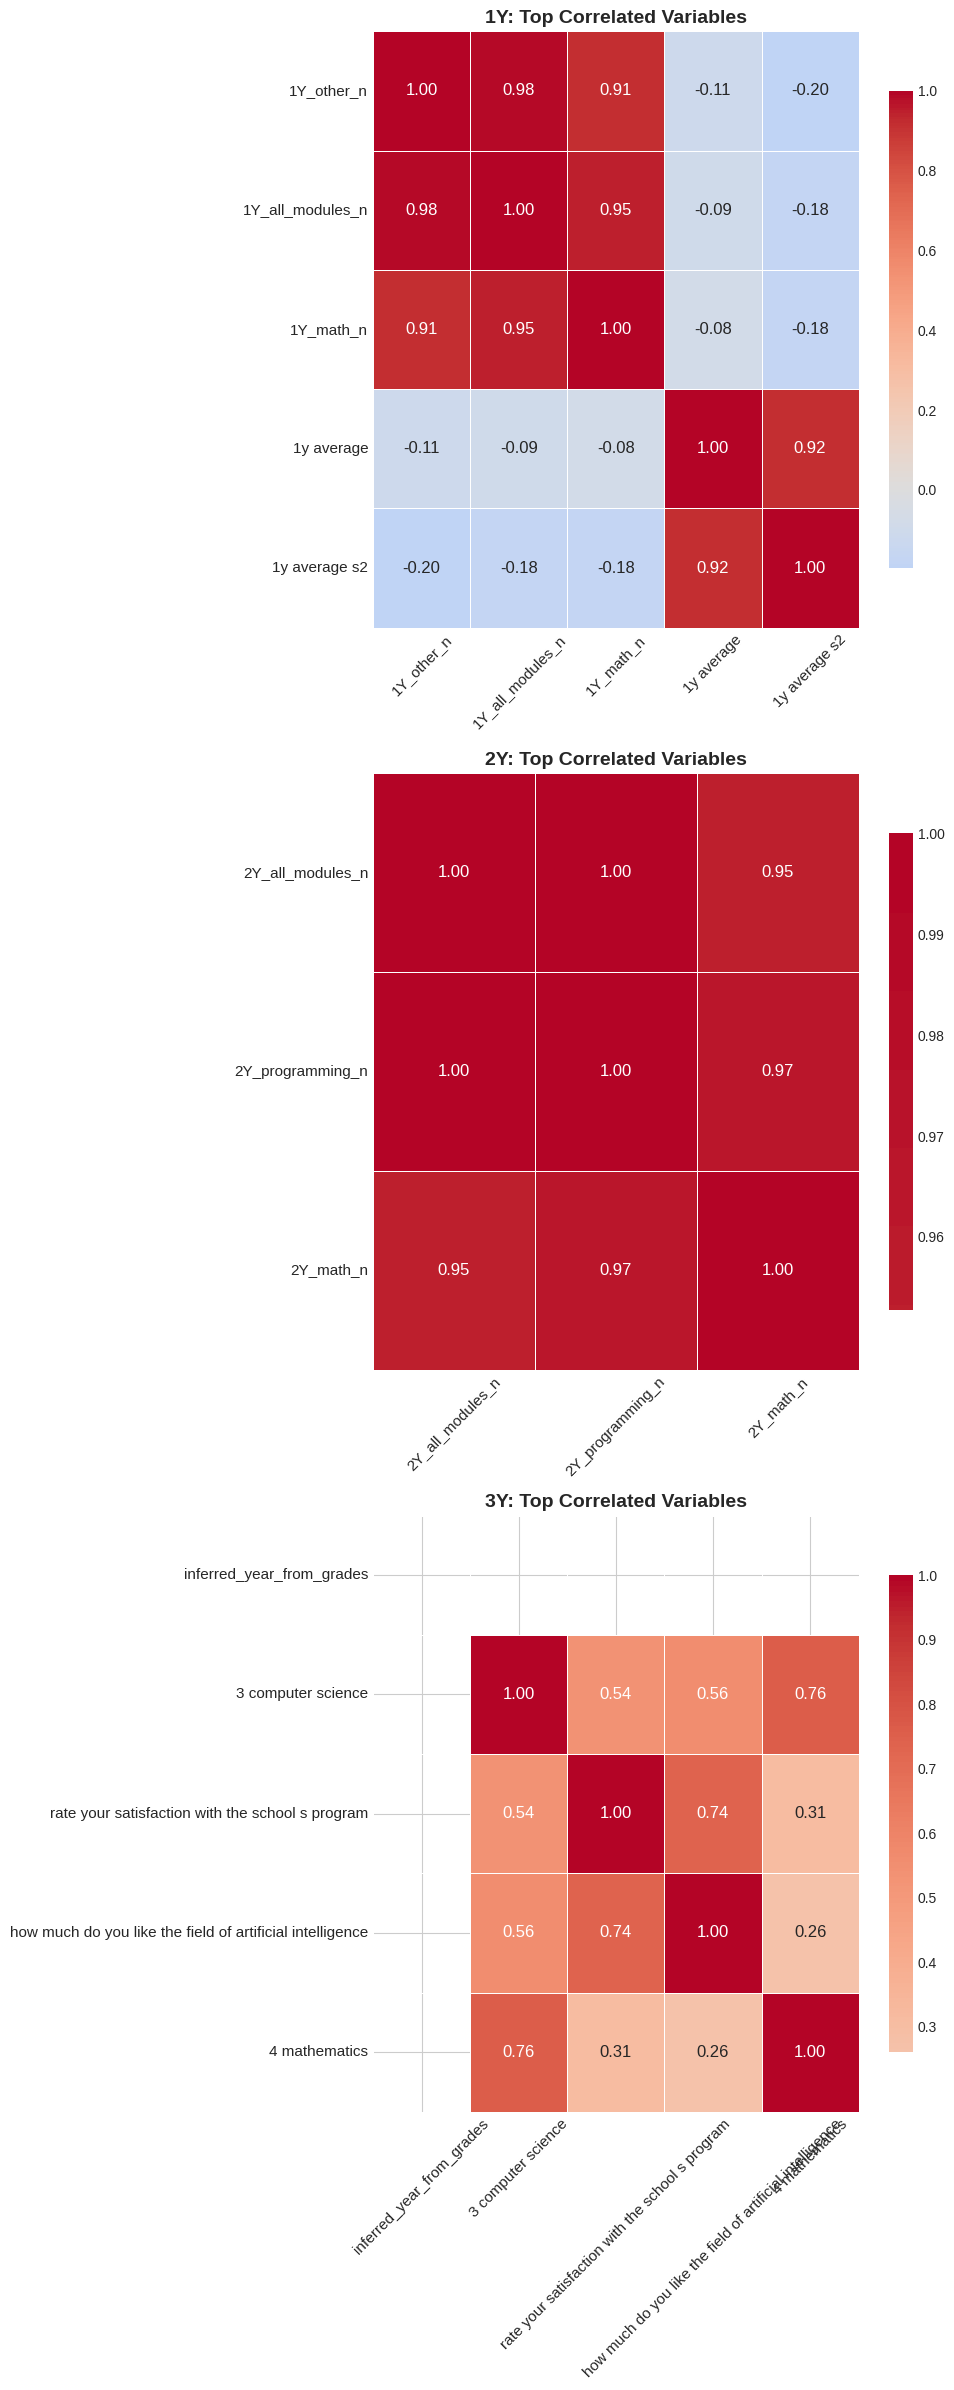

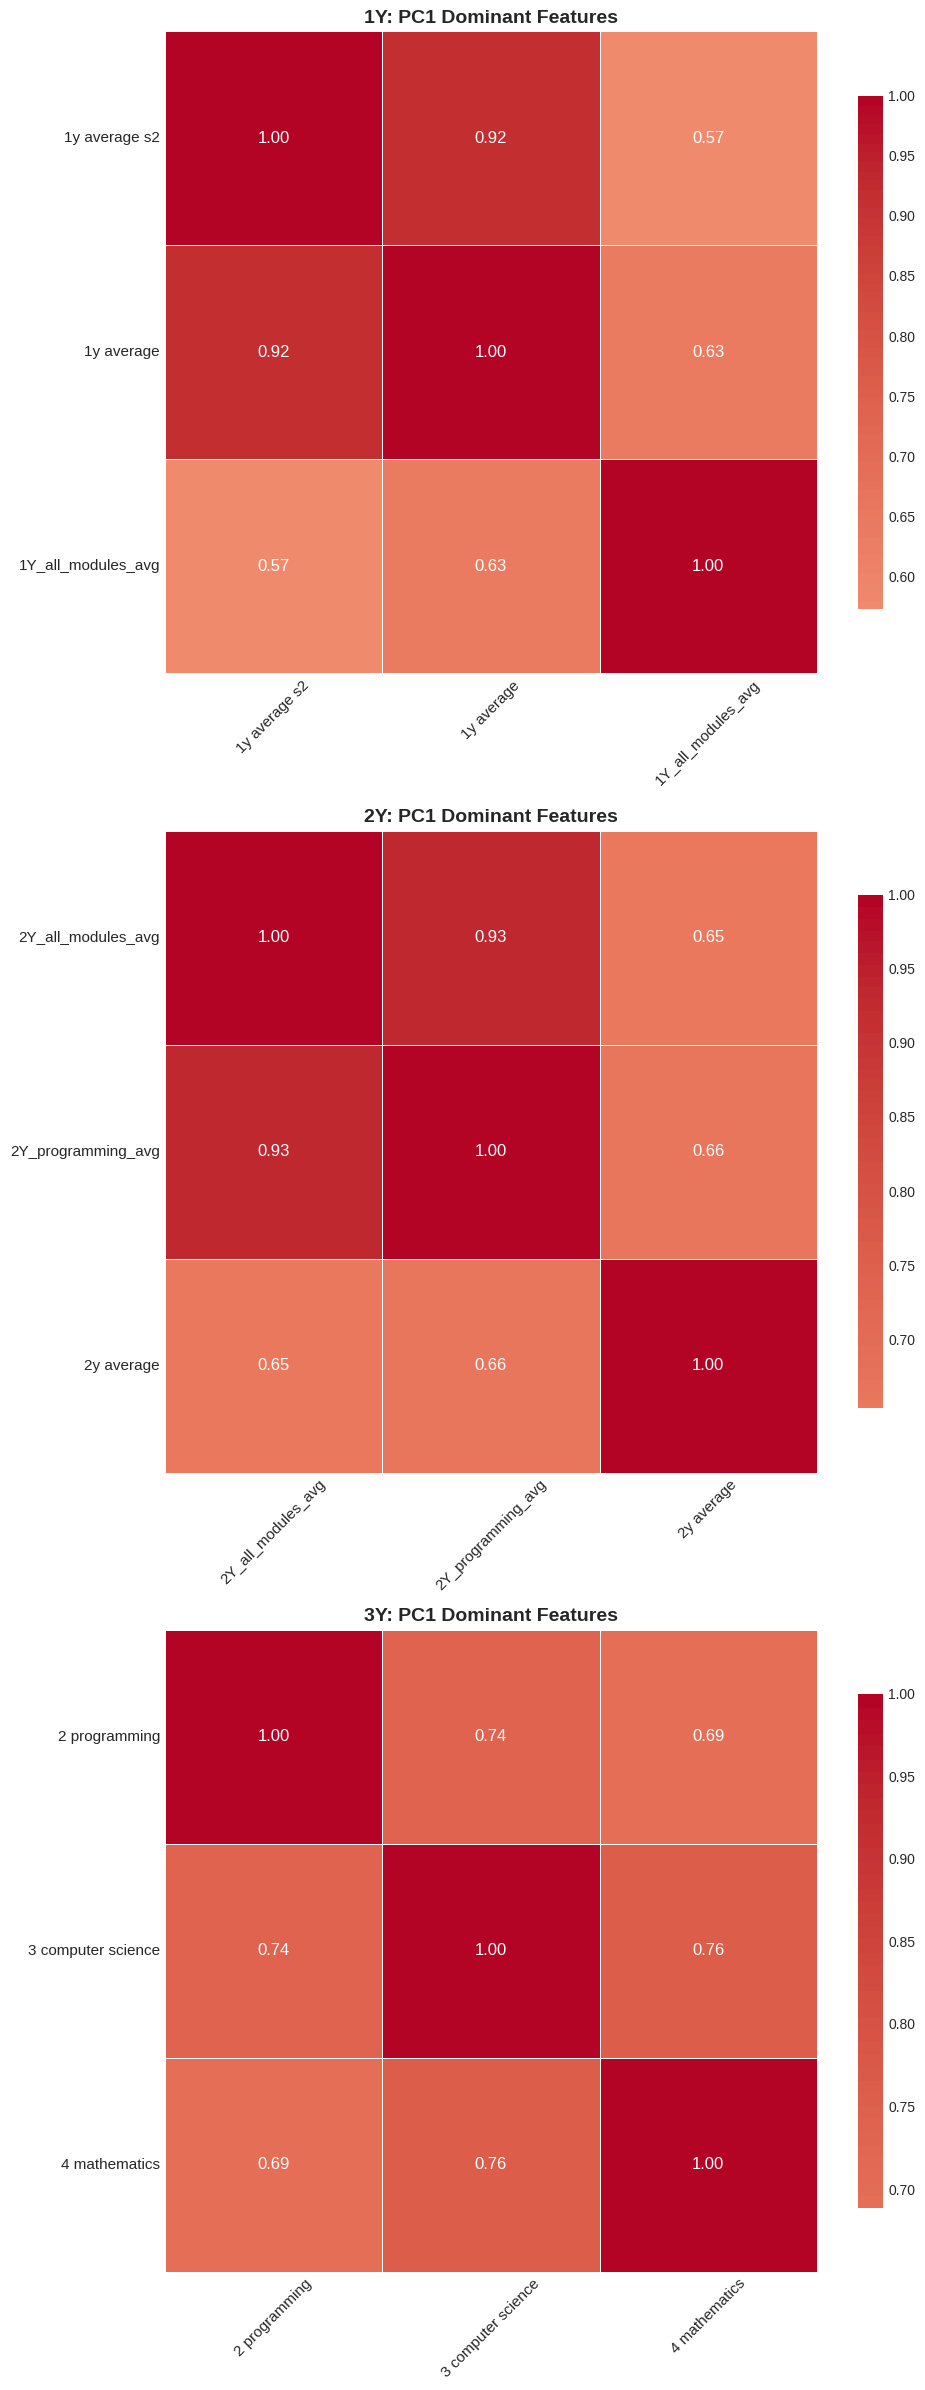

In [24]:
# Visualize the selected subsets with focused correlation matrices
print("\n" + "="*80)
print("FOCUSED CORRELATION MATRICES FOR SELECTED SUBSETS")
print("="*80)

# Top correlated variables
fig, axes = plt.subplots(3, 1, figsize=(10, 24))

for idx, (year, data, corr_mat) in enumerate([
    ('1Y', numeric_1y, pearson_1y),
    ('2Y', numeric_2y, pearson_2y),
    ('3Y', numeric_3y, pearson_3y)
]):
    subset_cols = recommended_subsets[year]['top_correlated']
    if len(subset_cols) >= 2:
        subset_corr = corr_mat.loc[subset_cols, subset_cols]
        sns.heatmap(subset_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
                    ax=axes[idx], linewidths=0.5, annot_kws={'size': 12},
                    cbar_kws={'shrink': 0.8})
        axes[idx].set_title(f'{year}: Top Correlated Variables', fontsize=14, fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45, labelsize=11)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=11)

plt.tight_layout()
plt.show()

# PC1 dominant features
fig, axes = plt.subplots(3, 1, figsize=(10, 24))

for idx, (year, data, corr_mat) in enumerate([
    ('1Y', numeric_1y, pearson_1y),
    ('2Y', numeric_2y, pearson_2y),
    ('3Y', numeric_3y, pearson_3y)
]):
    subset_cols = recommended_subsets[year]['pc1_features']
    if len(subset_cols) >= 2:
        subset_corr = corr_mat.loc[subset_cols, subset_cols]
        sns.heatmap(subset_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f',
                    ax=axes[idx], linewidths=0.5, annot_kws={'size': 12},
                    cbar_kws={'shrink': 0.8})
        axes[idx].set_title(f'{year}: PC1 Dominant Features', fontsize=14, fontweight='bold')
        axes[idx].tick_params(axis='x', rotation=45, labelsize=11)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=11)

plt.tight_layout()
plt.show()

In [25]:
# Export selected subsets for further analysis
print("\n" + "="*80)
print("SELECTED SUBSETS FOR FURTHER ANALYSIS")
print("="*80)
print("\nThese subsets are stored in 'recommended_subsets' dictionary for use in focused analysis.\n")

# Display final subset summary
for year in ['1Y', '2Y', '3Y']:
    print(f"\n{year} Subsets:")
    print(f"  * top_correlated: {recommended_subsets[year]['top_correlated']}")
    print(f"  * pc1_features: {recommended_subsets[year]['pc1_features']}")
    print(f"  * pc2_features: {recommended_subsets[year]['pc2_features']}")

print("\n" + "="*80)
print("Subset selection complete!")
print("Use 'recommended_subsets' dictionary to access these variables for focused analysis.")
print("="*80)


SELECTED SUBSETS FOR FURTHER ANALYSIS

These subsets are stored in 'recommended_subsets' dictionary for use in focused analysis.


1Y Subsets:
  * top_correlated: ['1Y_other_n', '1Y_all_modules_n', '1Y_math_n', '1y average', '1y average s2']
  * pc1_features: ['1y average s2', '1y average', '1Y_all_modules_avg']
  * pc2_features: ['1Y_all_modules_n', '1Y_other_n', '1Y_math_n']

2Y Subsets:
  * top_correlated: ['2Y_all_modules_n', '2Y_programming_n', '2Y_math_n']
  * pc1_features: ['2Y_all_modules_avg', '2Y_programming_avg', '2y average']
  * pc2_features: ['2Y_all_modules_n', '2Y_programming_n', '2Y_math_n']

3Y Subsets:
  * top_correlated: ['inferred_year_from_grades', '3 computer science', 'rate your satisfaction with the school s program', 'how much do you like the field of artificial intelligence', '4 mathematics']
  * pc1_features: ['2 programming', '3 computer science', '4 mathematics']
  * pc2_features: ['3Y_math_n', '3Y_programming_n', '3Y_other_n']

Subset selection complete!